In [617]:
# importing necessary packages 
import numpy as np
import pandas as pd
from os import path
from PIL import Image
import statsmodels.api as sm
import nltk; nltk.download('punkt'); nltk.download('stopwords')
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/gracecwilkins/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gracecwilkins/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [618]:
# read in demographics file 
demographics = pd.read_csv("data/Dartmouth Data Set- SIRS .xlsx - Demographics.csv")
print(demographics.head())
print(demographics.shape)
print(demographics['Local ID'].nunique())

# get local IDs
local_ids = demographics['Local ID']

   Local ID Date Enrolled in START  Status Status Date  \
0  11128335               7/1/2010  Active   7/22/2010   
1  11134104              11/1/2011  Active  11/30/2011   
2  11138520               5/1/2012  Active   5/21/2012   
3  11132094               5/1/2013  Active    5/9/2013   
4   975134C               7/1/2014  Active    7/1/2014   

                       Time Enrolled in START  \
0  Business Hours (Monday - Friday 8am - 5pm)   
1  Business Hours (Monday - Friday 8am - 5pm)   
2  Business Hours (Monday - Friday 8am - 5pm)   
3  Business Hours (Monday - Friday 8am - 5pm)   
4  Business Hours (Monday - Friday 8am - 5pm)   

        Source of referral to START Suitability of enrollment in START  \
0  Case Manager/Service Coordinator                        Appropriate   
1  Case Manager/Service Coordinator                        Appropriate   
2  Case Manager/Service Coordinator                        Appropriate   
3  Case Manager/Service Coordinator                        A

In [619]:
# read in ABC score file 
abc = pd.read_csv("data/Dartmouth Data Set- SIRS .xlsx - ABC Data.csv")
print(abc.head())
print(abc.shape)


print(abc['Local ID'].nunique())

# filter out entries not represented in demographic data 
abc_filtered = abc[abc['Local ID'].isin(local_ids)]
print(abc_filtered['Local ID'].nunique())

   Local ID Date Reviewed Type of Service  Irritability/Agitation  \
0  11163106      2/1/2013          Intake                     9.0   
1  11163106      2/1/2013          Intake                     9.0   
2  11134102      3/1/2013          Intake                    21.0   
3  11134102      3/1/2013          Intake                    21.0   
4  11134102     11/1/2014   Re-evaluation                    15.0   

   Lethargy/Social Withdrawal  Stereotypic Behavior  \
0                        16.0                   0.0   
1                        16.0                   0.0   
2                        21.0                   2.0   
3                        21.0                   2.0   
4                        11.0                   2.0   

   Hyperactivity/Noncompliance  Inappropriate Speech  
0                          0.0                   0.0  
1                          0.0                   0.0  
2                          9.0                   2.0  
3                          9.0    

In [620]:
# merge ABC and demographic files based on local ID 
merged = pd.merge(abc_filtered,
                  demographics, on="Local ID")
print(merged[['Presenting problems at time of enrollment']])

               Presenting problems at time of enrollment
0      Aggression (physical, verbal, property destruc...
1      Aggression (physical, verbal, property destruc...
2      Aggression (physical, verbal, property destruc...
3      Aggression (physical, verbal, property destruc...
4      Aggression (physical, verbal, property destruc...
5      Aggression (physical, verbal, property destruc...
6      Aggression (physical, verbal, property destruc...
7      Aggression (physical, verbal, property destruc...
8      Aggression (physical, verbal, property destruc...
9      Aggression (physical, verbal, property destruc...
10     Aggression (physical, verbal, property destruc...
11     Aggression (physical, verbal, property destruc...
12     Aggression (physical, verbal, property destruc...
13     Aggression (physical, verbal, property destruc...
14     Aggression (physical, verbal, property destruc...
15     Aggression (physical, verbal, property destruc...
16     Aggression (physical, ve

In [621]:
# normalize ABC scores to be on a scale from 0-100 
def normalize_to_100(value, max_value):
    return (value / max_value) * 100

merged['norm_leth_soc'] = merged['Lethargy/Social Withdrawal'].apply(lambda x: normalize_to_100(x, 48))
merged['norm_ir_agit'] = merged['Irritability/Agitation'].apply(lambda x: normalize_to_100(x, 45))
merged['norm_stereo'] = merged['Stereotypic Behavior'].apply(lambda x: normalize_to_100(x, 21))
merged['norm_hyper'] = merged['Hyperactivity/Noncompliance'].apply(lambda x: normalize_to_100(x, 48))
merged['norm_speech'] = merged['Inappropriate Speech'].apply(lambda x: normalize_to_100(x, 12))

merged.head()

,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech,Date Enrolled in START,Status,Status Date,Time Enrolled in START,Source of referral to START,Suitability of enrollment in START,Individual/Caregiver reliable access to technology,Presenting problems at time of enrollment,Services at Enrollment,DOB,Gender,Race,Ethnicity,Level of Intellectual Disability,Current living situation at enrollment to START,More than one living situation over the last 5 years?,More than one living situation over the last year?,Psychiatric hospitalization in past year (at enrollment to START),Psychiatric hospitalizations in past 1 - 5 years (at enrollment to START),Emergency department visits in past year (at enrollment to START),Emergency department visits in past 1-5 years (at enrollment to START),Law enforcement encounters in past year (at enrollment to START),Law enforcement encounters in past 1 - 5 years (at enrollment to START),Psychiatric diagnoses,Medical diagnoses,Other Disabilities,Cause/etiology of disability,Who is the individual's primary caregiver?,Does the individual have a secondary caregiver?,Does the individual have a legal guardian?,Funding,History of Child Protective Services involvement in past year (at enrollment to START),History of Child Protective Services involvement in lifetime (at enrollment to START),State sponsored ICF/DD stay in past year (at enrollment to START),State sponsored ICF/DD stay in past 1 - 5 years (at enrollment to START),Jailed in the past year (at enrollment to START),Jailed in the past 1 - 5 years (at enrollment to START),Employment Status at Enrollment,Grade In School,Current IEP,Current 504 Plan,School Setting,Custody Status,Child Lives With,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech
0,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0,4/1/2013,Active,7/18/2019,Business Hours (Monday - Friday 8am - 5pm),Case Manager/Service Coordinator,Appropriate,"Cell phone service, High speed internet, Smart...","Aggression (physical, verbal, property destruc...","Behavioral support services, Case management/s...",1/1/1991,Female,White,Not of Hispanic origin,Mild,Alternative Family Living (AFL),Yes,Yes: 4,No,Yes: 1,No,No,NaN,NaN,"Borderline Personality Disorder, Major Depress...","Ear/Nose/Throat, Eye disorders (2005), Obesity...","Hearing, Speech/Communication, Vision (2005)",Other: Whooping Cough,Paid support staff,Yes: Parent,Yes: Other appointed guardian,"I/DD waiver, Medicaid",No,No,No,No,No,No,Employment (PT),NaN,No,No,NaN,NaN,NaN,4.166667,6.666667,0.000000,0.000000,0.000000
1,11153125,4/11/2017,Re-evaluation,3.0,2.0,NaN,NaN,NaN,4/1/2013,Active,7/18/2019,Business Hours (Monday - Friday 8am - 5pm),Case Manager/Service Coordinator,Appropriate,"Cell phone service, High speed internet, Smart...","Aggression (physical, verbal, property destruc...","Behavioral support services, Case management/s...",1/1/1991,Female,White,Not of Hispanic origin,Mild,Alternative Family Living (AFL),Yes,Yes: 4,No,Yes: 1,No,No,NaN,NaN,"Borderline Personality Disorder, Major Depress...","Ear/Nose/Throat, Eye disorders (2005), Obesity...","Hearing, Speech/Communication, Vision (2005)",Other: Whooping Cough,Paid support staff,Yes: Parent,Yes: Other appointed guardian,"I/DD waiver, Medicaid",No,No,No,No,No,No,Employment (PT),NaN,No,No,NaN,NaN,NaN,4.166667,6.666667,NaN,NaN,NaN
2,11153125,10/11/2017,Re-evaluation,2.0,1.0,0.0,0.0,NaN,4/1/2013,Active,7/18/2019,Business Hours (Monday - Friday 8am - 5pm),Case Manager/Service Coordinator,Appropriate,"Cell phone service, High speed internet, Smart...","Aggression (physical, verbal, property destruc...","Behavioral support services, Case management/s...",1/1/1991,Female,White,Not of Hispanic origin,Mild,Alternative Family Living (AFL),Yes,Yes: 4,No,Yes: 1,No,No,NaN,NaN,"Borderline Personality Disorder, Major Depress...","Ear/Nose/Throat, Eye disorders (2005), Obesity...","H

In [622]:
# dictionary with labels for each ABC score 
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

# filter to type of service and normalized ABC scores 
columns_of_interest = ['Type of Service', 'norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']
df_analysis = merged[columns_of_interest]

# Map Re-evaluation to 1 and Intake to 0
df_analysis['Type of Service'] = df_analysis['Type of Service'].map({'Intake': 0, 'Re-evaluation': 1})  
df_analysis = df_analysis.dropna()

X = df_analysis['Type of Service']
y = df_analysis.iloc[:, 1:]

X = sm.add_constant(X)

# run regression model 
for col in y.columns:
    model = sm.OLS(y[col], X).fit()
    print(f"Regression results for {col}:")
    print(model.summary())




/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_25145/1099077057.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['Type of Service'] = df_analysis['Type of Service'].map({'Intake': 0, 'Re-evaluation': 1})


Regression results for norm_leth_soc:
                            OLS Regression Results                            
Dep. Variable:          norm_leth_soc   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     544.7
Date:                Wed, 29 May 2024   Prob (F-statistic):          8.00e-119
Time:                        16:54:03   Log-Likelihood:                -82653.
No. Observations:               19226   AIC:                         1.653e+05
Df Residuals:                   19224   BIC:                         1.653e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons

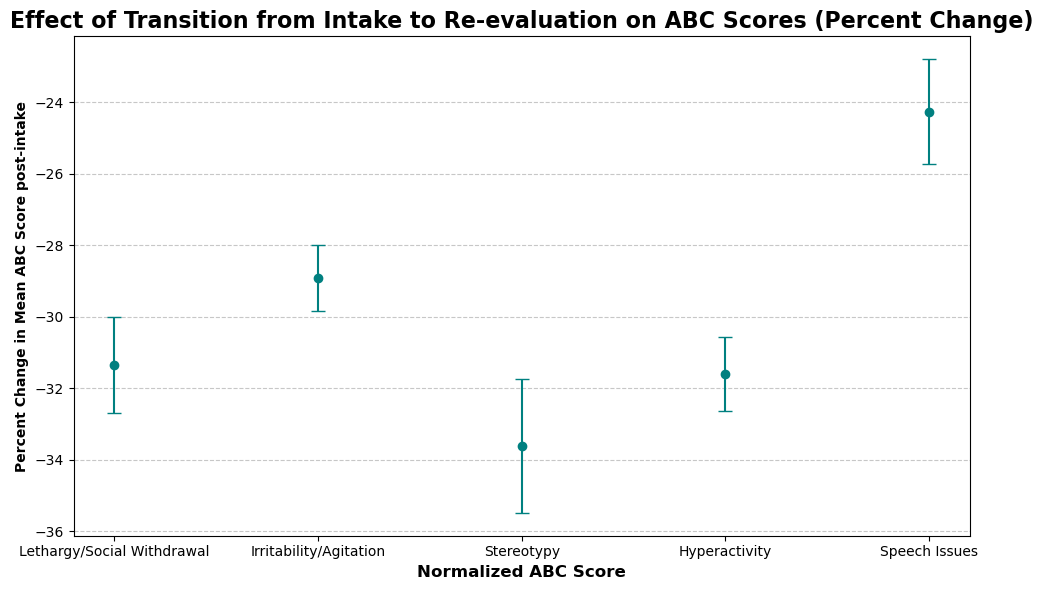

In [623]:
# plotting change in mean ABC score based on intake/re-eval for each type of ABC score 

means = y.mean()


coefficients = []
std_errors = []
for col in y.columns:
    model = sm.OLS(y[col], X).fit()
    coefficients.append(model.params['Type of Service'] / means[col] * 100)
    std_errors.append(model.bse['Type of Service'] / means[col] * 100)

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(y.columns)), coefficients, yerr=std_errors, fmt='o', capsize=5, color='teal')
plt.xticks(range(len(y.columns)), [rename_dict[col] for col in y.columns])
plt.xlabel('Normalized ABC Score', fontsize=12, fontweight='bold')
plt.ylabel('Percent Change in Mean ABC Score post-intake', fontsize=10, fontweight='bold')
plt.title('Effect of Transition from Intake to Re-evaluation on ABC Scores (Percent Change)', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [633]:
# get sentiments for every entry 
merged.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)

# intialize sentiment object 
sent_obj = SentimentIntensityAnalyzer()

# function to analyze sentiment 
def clean_and_analyze_sentiment(entry):
    sentiment_scores = sent_obj.polarity_scores(entry)
    return sentiment_scores

merged["sentiments"] = merged['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

merged["sentiments"].head()

0    {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
1    {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
2    {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
3    {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
4    {'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...
Name: sentiments, dtype: object

In [634]:
sentiment_df = pd.DataFrame(merged['sentiments'].tolist())

# plt.figure(figsize=(10, 6))

# sentiment_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
# plt.title('Average Sentiment Scores')
# plt.xlabel('Sentiment')
# plt.ylabel('Average Score')
# plt.xticks(rotation=0)
# plt.show()
# plt.savefig('output/sentiment_figure.png')

# sentiment_df.compound.mean

In [64]:
# ANNA: separating intake and re-eval 

# # re-eval subset
# reeval_subset = merged[merged['Type of Service'] == "Re-evaluation"]
# print(reeval_subset.shape)

# #intake subset
# intake_subset = merged[merged['Type of Service'] == "Intake"]
# print(intake_subset.shape)

# merged.shape

# merged['Type of Service'].unique()


# sentiments = []
# reeval_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
# sent_obj = SentimentIntensityAnalyzer()

# reeval_subset["sentiments"] = reeval_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

# reeval_subset["sentiments"]


# reeval_df = pd.DataFrame(reeval_subset['sentiments'].tolist())

# plt.figure(figsize=(10, 6))
# reeval_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
# plt.title('Average Sentiment Scores')
# plt.xlabel('Sentiment')
# plt.ylabel('Average Score')
# plt.xticks(rotation=0)
# plt.show()
# plt.savefig('output/sentiment_reeval.png')

# reeval_df.compound.mean


#  look at if the compound score changes at all for different races 



In [63]:
# sentiments = []
# intake_subset.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
# sent_obj = SentimentIntensityAnalyzer()

# intake_subset["sentiments"] = intake_subset['Presenting problems at time of enrollment'].apply(clean_and_analyze_sentiment)

# intake_subset["sentiments"]


# intake_df = pd.DataFrame(intake_subset['sentiments'].tolist())

# plt.figure(figsize=(10, 6))
# intake_df.mean().plot(kind='bar', color=['pink', 'purple', 'salmon', 'plum'], alpha=0.7)
# plt.title('Average Sentiment Scores')
# plt.xlabel('Sentiment')
# plt.ylabel('Average Score')
# plt.xticks(rotation=0)
# plt.show()
# plt.savefig('output/sentiment_intake.png')
# intake_df.compound.mean

/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_25145/2801903410.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reeval_subset["compound_sentiment"] = reeval_subset['sentiments'].apply(lambda x: x['compound'])
/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_25145/2801903410.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intake_subset["compound_sentiment"] = intake_subset['sentiments'].apply(lambda x: x['compound'])


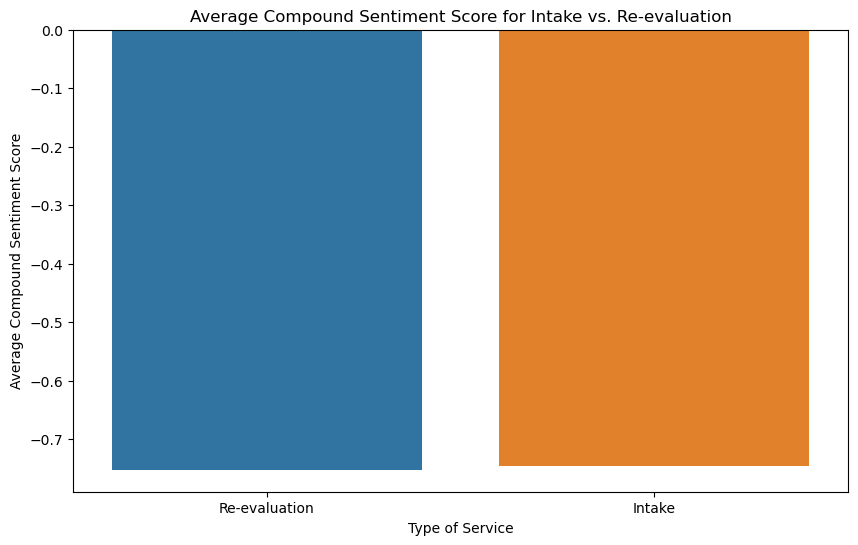

In [636]:
#Grace sentiment compound analysis INTAKE VS REEVAL 

# Filter subsets for "Re-evaluation" and "Intake"
reeval_subset = merged[merged['Type of Service'] == "Re-evaluation"]
intake_subset = merged[merged['Type of Service'] == "Intake"]

# select just compound sentiment 
reeval_subset["compound_sentiment"] = reeval_subset['sentiments'].apply(lambda x: x['compound'])
intake_subset["compound_sentiment"] = intake_subset['sentiments'].apply(lambda x: x['compound'])

# take mean compound sentiment based on intake or re-eval 
avg_reeval_sentiment = reeval_subset["compound_sentiment"].mean()
avg_intake_sentiment = intake_subset["compound_sentiment"].mean()

avg_sentiments_df = pd.DataFrame({
    "Type of Service": ["Re-evaluation", "Intake"],
    "Average Compound Sentiment": [avg_reeval_sentiment, avg_intake_sentiment]
})


avg_sentiments_df

# plot average compound sentiment intake and re-eval 
plt.figure(figsize=(10, 6))
sns.barplot(x="Type of Service", y="Average Compound Sentiment", data=avg_sentiments_df)
plt.title("Average Compound Sentiment Score for Intake vs. Re-evaluation")
plt.ylabel("Average Compound Sentiment Score")
plt.xlabel("Type of Service")
plt.show()


In [637]:
# Grace  

grouped_service = merged.groupby('Type of Service')

# Calculate mean/median of normalized ABC scores for each type of score
mean_abc_scores = grouped_service[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()
median_abc_scores = grouped_service[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].median()

# Print mean and median ABC scores for intake VS reevaluation
print("Mean ABC Scores by Type of Service:")
print(mean_abc_scores)

print("Median ABC Scores by Type of Service:")
print(median_abc_scores)




Mean ABC Scores by Type of Service:
                           norm_leth_soc  norm_ir_agit  norm_stereo  \
Type of Service                                                       
Intake                         26.969068     48.840795    25.318666   
Re-evaluation                  20.082151     37.151033    18.492202   
Resource Center admission      19.847670     31.254480    12.454212   

                           norm_hyper  norm_speech  
Type of Service                                     
Intake                      46.043439    37.100480  
Re-evaluation               34.168355    29.463744  
Resource Center admission   25.452899    26.902174  
Median ABC Scores by Type of Service:
                           norm_leth_soc  norm_ir_agit  norm_stereo  \
Type of Service                                                       
Intake                         22.916667     48.888889    14.285714   
Re-evaluation                  14.583333     35.555556     9.523810   
Resource Center admis

In [638]:

# Grace's GENDER analysis 
gender_mapping = {
    'Female': 'Female',
    'Male': 'Male',
    'Other:': 'Other:',
    'Other: Born male, unsure of gender identity at this time': 'Other:',
    'Other: Born male/ he/ him, Currently identifies as female/ she/ her': 'Other:',
    'Other: Desires to transition from male to female': 'Other:',
    'Other: Identifies as female': 'Other:',
    'Other: Transgender female': 'Other:',
    'Other: biologically female. self describes as male': 'Other:',
    'Other: currently exploring male and female gender identities': 'Other:',
    'Other: non binary': 'Other:',
    'Other: not sure yet as to who Sam identifies with': 'Other:'
}

# Apply all of this gender mapping to the Gender column
merged['Gender'] = merged['Gender'].map(gender_mapping).fillna('Other:')


# find mean ABC scores based on type of service and gender 
abc_by_gender = merged.groupby(['Type of Service', 'Gender'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()
counts = merged.groupby(['Type of Service', 'Gender']).size().reset_index(name='counts')

abc_by_gender_with_counts = abc_by_gender.merge(counts, on=['Type of Service', 'Gender'])
print("Mean ABC Scores by Gender and Type of Service:")
abc_by_gender_with_counts

Mean ABC Scores by Gender and Type of Service:


,Type of Service,Gender,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,counts
0,Intake,Female,26.275510,51.473923,20.504128,43.016645,35.168095,1525
1,Intake,Male,27.277615,47.727317,27.473926,47.435709,37.984724,3418
2,Intake,Other:,27.083333,32.222222,22.222222,33.159722,30.555556,12
3,Re-evaluation,Female,19.024962,39.264770,14.394479,30.937284,27.594438,4849
4,Re-evaluation,Male,20.638055,36.072176,20.599183,35.828568,30.414853,9468
5,Re-evaluation,Other:,17.005814,36.279070,16.057586,32.509690,30.620155,43
6,Resource Center admission,Female,19.120370,30.814815,9.632035,20.648148,23.703704,45
7,Resource Center admission,Male,20.529514,31.666667,15.096251,30.053191,29.964539,48


In [639]:
# Grace

# Define a mapping dictionary for the new categories
race_mapping = {
    'White': 'White',
    'Black or African American': 'African American',
    'Unknown, not collected': 'Unknown',
    'Other: Hispanic': 'Hispanic',
    'Asian': 'Asian',
    'Other': 'Other',
    'Black or African American, White': 'Multiracial',
    'Other: Latino': 'Hispanic',
    'American Indian or Alaska Native': 'Native',
    'Other: hispanic': 'Hispanic',
    'Asian, White': 'Multiracial',
    'Other: Mexican': 'Hispanic',
    'Unknown, not collected, White': 'Unknown',
    'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
    'Other: Biracial': 'Multiracial',
    'Other: Hispanic, White': 'Multiracial',
    'Other: Bi-racial': 'Multiracial',
    'Other: East Indian': 'Asian',
    'Asian, Black or African American': 'Multiracial',
    'Other: Indian': 'Asian',
    'Black or African American, Unknown, not collected': 'Multiracial',
    'Other: Middle Eastern': 'Other',
    'American Indian or Alaska Native, White': 'Multiracial',
    'Other: Guyanese': 'Unknown',
    'Other: Filipino': 'Unknown',
    'Other: Hispanic - Puerto Rican descent': 'Hispanic',
    'Other: Puerto Rican': 'Hispanic',
    'Other: Mixed race': 'Multiracial',
    'Other: Mixed Race': 'Multiracial',
    'Native Hawaiian or Other Pacific Islander, White': 'Multiracial',
    'Other: "Hispanic"': 'Hispanic',
    'Other: Latina': 'Hispanic',
    'Other: Latin  American': 'Hispanic',
    'Other: Jordanian': 'Unknown',
    'Other: Pakistan, Unknown, not collected': 'Unknown',
    'Other: Hispanic/Latino': 'Hispanic',
    'Black or African American, Other: Hispanic': 'Multiracial',
    'Black or African American, Other: Guyanese': 'Multiracial',
    'Other: Russian': 'Unknown',
    'Other: West Indian': 'Unknown',
    'Asian, Other: Indian': 'Multiracial',
    'Other: HISPANIC': 'Hispanic',
    'Other: Guyanses': 'Unknown',
    'Asian, Other: Pakistani': 'Asian',
    'American Indian or Alaska Native, Black or African American': 'Multiracial',
    'Other: Ethiopian': 'Unknown',
    'Other: Egyptian': 'Unknown',
    'Other: biracial': 'Multiracial',
    'Other: Colombian': 'Unknown',
    'Other: Did not want to Identity with Race or Ethnicity': 'Unknown',
    'Other: Dominican': 'Unknown',
    'Other: Chinese': 'Unknown',
    'Other: Eastern European': 'Unknown',
    'Other: Ecuador': 'Unknown',
    'Other: Ecuadorian': 'Unknown',
    'Other: Caucasian and African Amercian': 'Multiracial',
    'Other: Caucasian': 'White',
    'Other: Eurasian': 'Multiracial',
    'Other: Carribean Indian': 'Other',
    'Other: Filipino and Caucasian': 'Multiracial',
    'Other: Bosnian': 'Other',
    'Other: Black Hispanic': 'Multiracial',
    'Other: HIspanic': 'Hispanic',
    'Other: Hispanic ': 'Hispanic',
    'Other: Hispanic (Uruguayan/Dominican)': 'Hispanic',
    'Other: Hispanic - Puerto Rican': 'Hispanic',
    'Other: Hispanic, AA and white': 'Multiracial',
    'Other: Hispanic, Unknown, not collected': 'Hispanic',
    'Other: Bi-Racial': 'Multiracial',
    'Other: Hispanic/ Latina': 'Hispanic',
    'Other: Bengalii': 'Other',
    'Other: Hispanic: Puerto Rican': 'Hispanic',
    'Other: Hondurian': 'Hispanic',
    'Other: Bengali': 'Other',
    'Other: Indian of Guyanese decent': 'Multiracial',
    'Other: Indian which decent unknown': 'Asian',
    'Other: Iraq': 'Unknown',
    'Other: Iraqi': 'Unknown',
    'Other: Irish': 'Unknown',
    'Other: Israel': 'Unknown',
    'Other: Jamaican American': 'African American',
    'Other: Jewish': 'Unknown',
    'Other: Bangladish': 'Unknown',
    'Other: Baltic ethnic group (Latvian)': 'Unknown',
    'Other: Arab': 'Other',
    'Other: Albian/European': 'Unknown',
    'Other: Latino ( Mexican & Puerto Rican )': 'Hispanic',
    'Other: Latino (Guatemalen & El Salvador)': 'Hispanic',
    'Other: Latino, White': 'Hispanic',
    'Other: MIXED RACE, White': 'Multiracial',
    'Other: MIddle Eastern- North African Descent, ': 'Other',
    'Other: Mauritius': 'Unknown',
    'Other: African-American/Vietnamese': 'Multiracial',
    'Other: Mexican/Puerto Rican': 'Unknown',
    'Other: Middle Eastern Decent': 'Other',
    'Other: South African': 'Unknown',
    'Other: South American': 'Unknown',
    'Other: Spanish': 'Unknown',
    'Other: Vietnamese': 'Unknown',
    'Other: Vietnamesse': 'Unknown',
    'Other: unknown': 'Unknown',
    'Other: White and Asian': 'Multiracial',
    'Other: White and Black or African America': 'Multiracial',
    'Other: puerto rican': 'Unknown',
    'Asian, Black or African American, White': 'Multiracial',
    'Asian, Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Asian, Other: Filipino': 'Multiracial',
    'Asian, Other: Hispanic': 'Multiracial',
    'Other: not checked off': 'Unknown',
    'Other: myanmar': 'Unknown',
    'Other: mother is white and father is 1/2 white': 'Multiracial',
    'Other: White, Hispanic': 'Multiracial',
    'Other: White/Indian': 'Multiracial',
    'Asian, Other: vietnamese': 'Multiracial',
    'Other: mixed race': 'Multiracial',
    'Other: hispanic, White': 'Multiracial',
    'Other: latino/white': 'Hispanic',
    'Other: mexican': 'Unknown',
    'American Indian or Alaska Native, Other: Native Hawaiian or Other Pacific Islander': 'Multiracial',
    'Other:': 'Other'  
}

# Group by "Type of Service" and "Race" and calculate mean ABC scores
merged['Race'] = merged['Race'].map(race_mapping).fillna('Other')
abc_by_race = merged.groupby(['Type of Service', 'Race'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()

# get counts for race demographics
race_counts = merged.groupby(['Type of Service', 'Race']).size().reset_index(name='Count')
abc_by_race_with_counts = pd.merge(abc_by_race, race_counts, on=['Type of Service', 'Race'])

intake_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Intake']
reeval_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Re-evaluation']
resource_center_data = abc_by_race_with_counts[abc_by_race_with_counts['Type of Service'] == 'Resource Center admission']

# sort data in descending count order based on # individuals in each category 
intake_data_sorted = intake_data.sort_values(by='Count', ascending=False)
reeval_data_sorted = reeval_data.sort_values(by='Count', ascending=False)
resource_center_data_sorted = resource_center_data.sort_values(by='Count', ascending=False)

# merge counts with race means 
abc_by_race_with_counts_sorted = pd.concat([intake_data_sorted, reeval_data_sorted, resource_center_data_sorted])

print("\nMean ABC Scores by Race and Type of Service with Counts (Sorted by Count within each Service Type):")
abc_by_race_with_counts_sorted




Mean ABC Scores by Race and Type of Service with Counts (Sorted by Count within each Service Type):


,Type of Service,Race,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,Count
8,Intake,White,26.209275,48.871164,24.256547,45.203827,36.895251,3014
0,Intake,African American,26.020999,47.491182,24.850895,46.787074,37.835821,1010
7,Intake,Unknown,29.079559,50.434448,26.729716,46.882234,37.833914,289
2,Intake,Hispanic,32.150901,49.987130,29.417172,47.691441,37.661499,261
1,Intake,Asian,30.666136,49.426752,30.815893,47.545117,37.101911,158
3,Intake,Multiracial,30.593093,51.211211,33.033033,52.834084,34.909910,111
5,Intake,Other,30.113636,50.764791,32.900433,47.808442,34.415584,78
4,Intake,Native,30.709877,49.300412,21.693122,46.682099,36.728395,27
6,Intake,Pacific Islander,22.321429,48.253968,23.809524,40.773810,34.523810,7
17,Re-evaluation,White,19.491877,37.015787,17.522212,33.431733,29.341380,8877


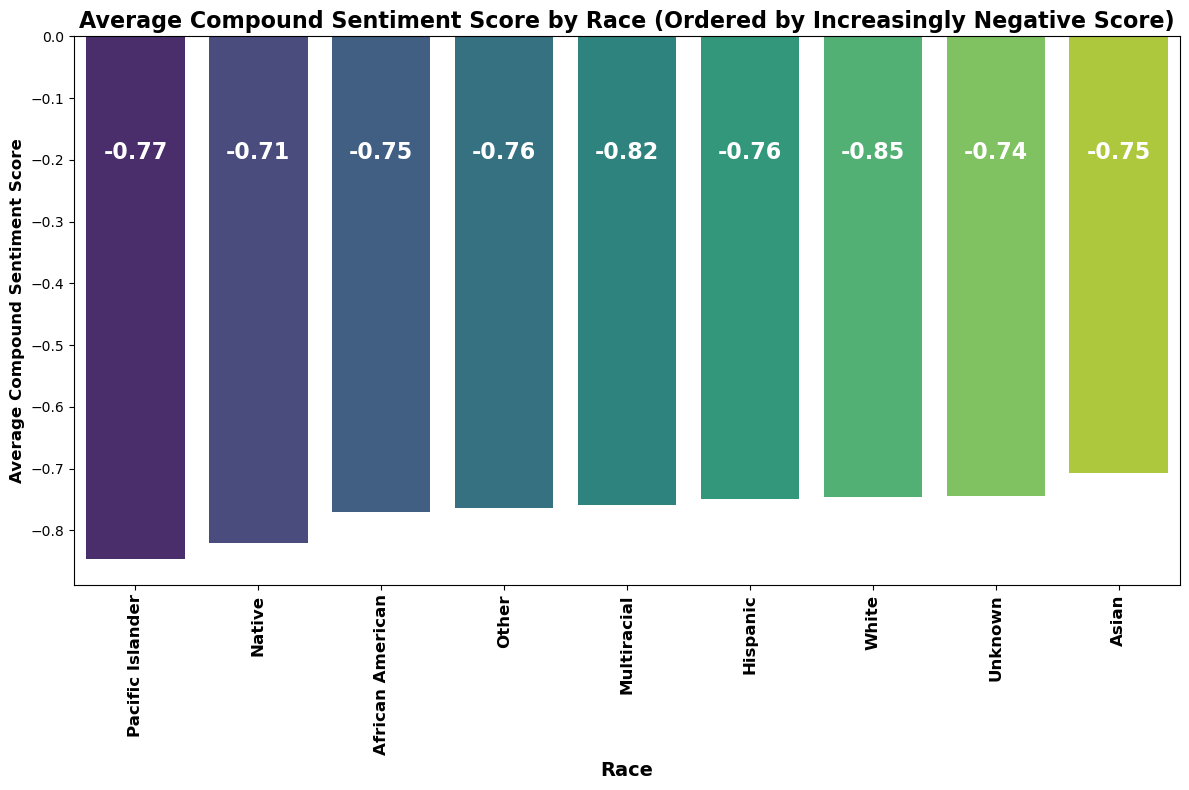

In [663]:
sentiment_by_race = merged.groupby('Race')['compound_score'].mean().reset_index()

# Sort by decreasingly negative score (reverse order)
sentiment_by_race_sorted = sentiment_by_race.sort_values(by='compound_score', ascending=True)

# Plot the results by race
plt.figure(figsize=(12, 8))
barplot = sns.barplot(data=sentiment_by_race_sorted, x='Race', y='compound_score', palette='viridis')

# Add the sentiment score above each bar, all at the same height
height = sentiment_by_race_sorted['compound_score'].max() + 0.5
for index, row in sentiment_by_race_sorted.iterrows():
    barplot.text(index, height, 
                 f'{row["compound_score"]:.2f}', 
                 color='white', 
                 ha="center", 
                 va="bottom", 
                 fontsize=16, 
                 fontweight='bold')

plt.title('Average Compound Sentiment Score by Race (Ordered by Increasingly Negative Score)', fontsize=16, fontweight='bold')
plt.xlabel('Race', fontsize=14, fontweight='bold')
plt.ylabel('Average Compound Sentiment Score', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold', rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [640]:
# select compound score out of sentiment scores 
merged["compound_score"] = merged["sentiments"].apply(lambda x: x['compound'])

# Group by race and calculate mean compound sentiment scores
sentiment_by_race = merged.groupby('Race')['compound_score'].mean().reset_index()
sentiment_by_race_sorted = sentiment_by_race.sort_values(by='compound_score')
sentiment_by_race_sorted



,Race,compound_score
6,Pacific Islander,-0.845513
4,Native,-0.820115
0,African American,-0.769286
5,Other,-0.762969
3,Multiracial,-0.759155
2,Hispanic,-0.748377
8,White,-0.745829
7,Unknown,-0.744513
1,Asian,-0.706123


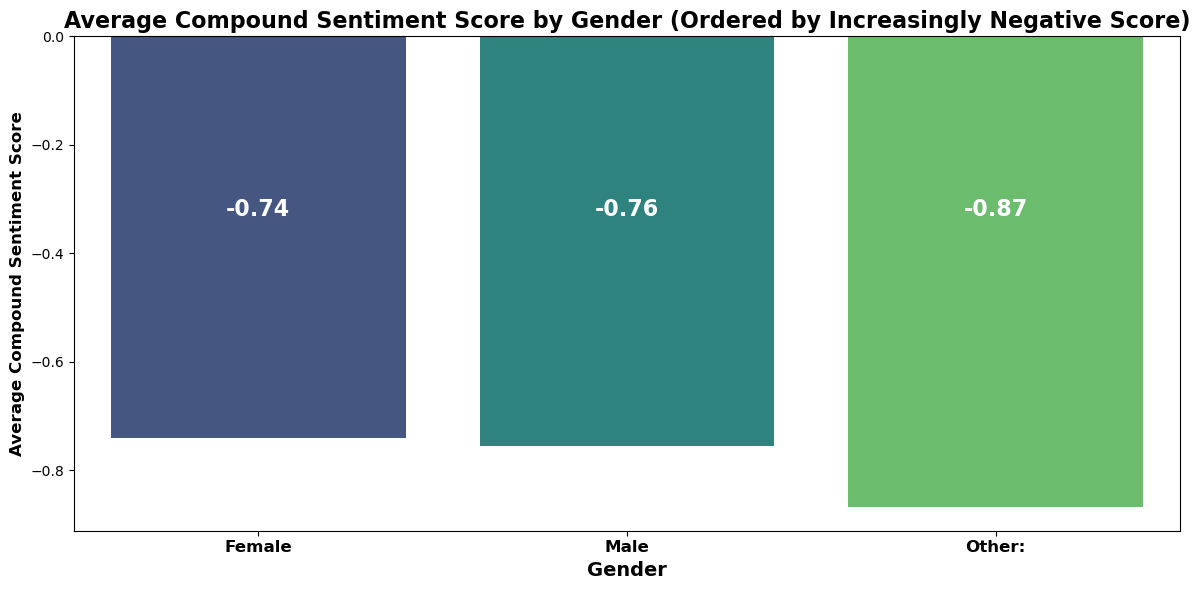

In [653]:

# Sort by decreasingly negative score (reverse order)
sentiment_by_gender_sorted = sentiment_by_gender.sort_values(by='compound_score', ascending=False)
sentiment_by_gender_sorted

# Plot the results by gender
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=sentiment_by_gender_sorted, x='Gender', y='compound_score', palette='viridis')

# Add the sentiment score above each bar, all at the same height
height = sentiment_by_gender_sorted['compound_score'].max() + 0.5  # Set a constant height above the highest bar
for index, row in sentiment_by_gender_sorted.iterrows():
    barplot.text(index, height, 
                 f'{row["compound_score"]:.2f}', 
                 color='White', 
                 ha="center", 
                 va="bottom", 
                 fontsize=16, 
                 fontweight='bold')

plt.title('Average Compound Sentiment Score by Gender (Ordered by Increasingly Negative Score)', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=14, fontweight='bold')
plt.ylabel('Average Compound Sentiment Score', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/gracecwilkins/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Topics found via LDA:
Topic 1: assistance daily participate
Topic 2: symptoms health mental
Topic 3: assistance threats aggression
Topic 4: destruction property physical


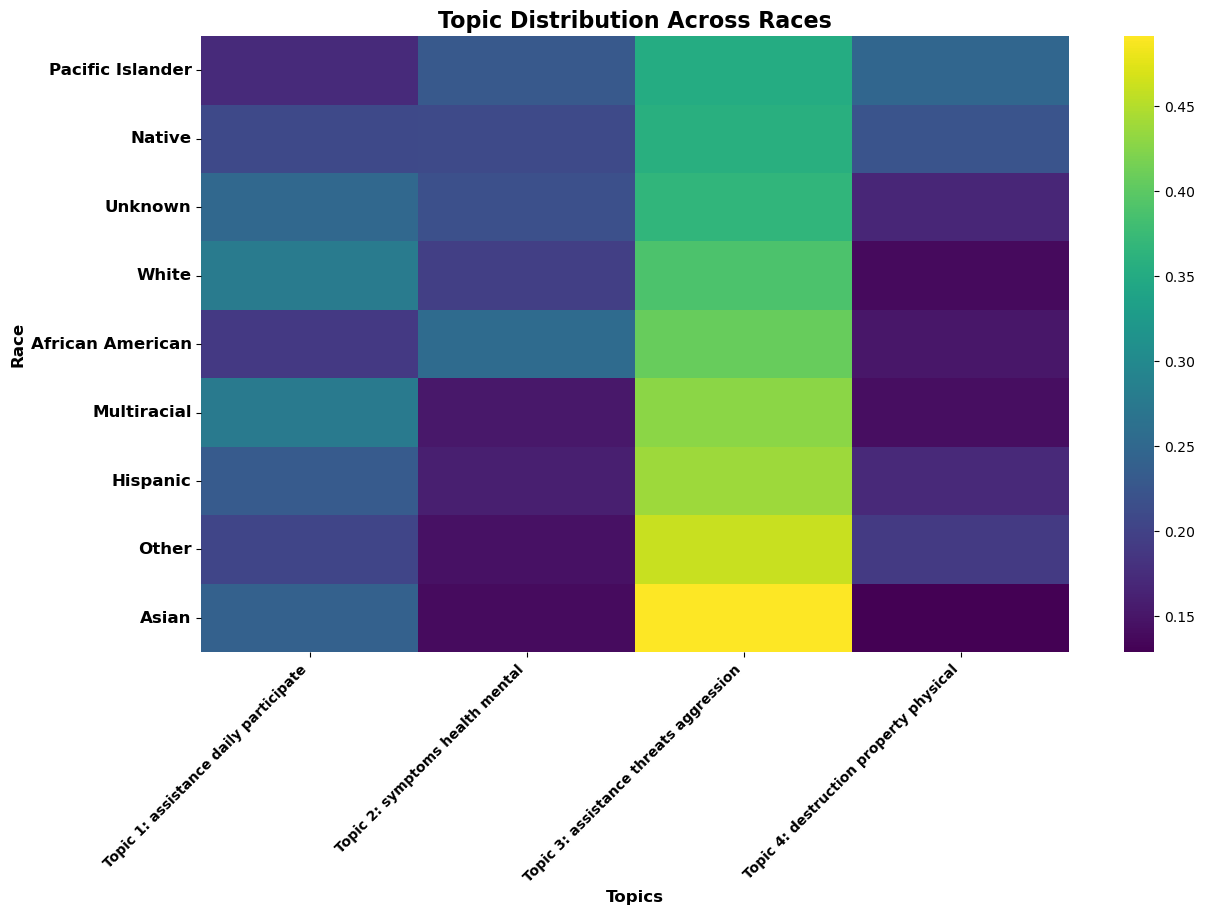

In [595]:

merged = merged.dropna(subset=['Presenting problems at time of enrollment'])
def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text)  
    text = re.sub(r'[^\w\s]', '', text)  
    text = text.lower()  
    return text
merged['cleaned_text'] = merged['Presenting problems at time of enrollment'].dropna().apply(preprocess_text)

# Tokenize text data
nltk.download('punkt')
merged['tokenized_text'] = merged['cleaned_text'].apply(word_tokenize)
# Vectorize text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
text_data = vectorizer.fit_transform(merged['cleaned_text'])


# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(text_data)

# Display topics
def display_topics(model, feature_names, no_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        topic_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(" ".join(topic_words))
    return topics

no_top_words = 3
feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, no_top_words)
print("Topics found via LDA:")
for idx, topic in enumerate(topics):
    print(f"Topic {idx+1}: {topic}")

# Use top words as topic labels
topic_labels = [f'Topic {i+1}: {" ".join(feature_names[topic.argsort()[:-no_top_words - 1:-1]])}' for i, topic in enumerate(lda.components_)]


# Group by Race and calculate topic distribution
topic_distribution = merged.groupby('Race')['cleaned_text'].apply(lambda texts: ' '.join(texts))
topic_distribution = topic_distribution.apply(preprocess_text)

# Vectorize grouped text data
grouped_text_data = vectorizer.transform(topic_distribution)
grouped_topics = lda.transform(grouped_text_data)

topic_df = pd.DataFrame(grouped_topics, index=topic_distribution.index, columns=topic_labels)

# Sort by severity of Topic 3
topic_df_sorted = topic_df.sort_values(by='Topic 3: ' + " ".join(feature_names[lda.components_[2].argsort()[:-no_top_words - 1:-1]]))

# Plot the topic distribution across races
plt.figure(figsize=(14, 8))
sns.heatmap(topic_df_sorted, annot=False, cmap='viridis')
plt.title('Topic Distribution Across Races', fontsize=16, fontweight='bold')
plt.xlabel('Topics', fontsize=12, fontweight='bold')
plt.ylabel('Race', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')  # Rotate topic labels for better readability
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


Topics found via LDA:
Topic 1: assistance daily participate
Topic 2: symptoms health mental
Topic 3: assistance threats aggression
Topic 4: destruction property physical


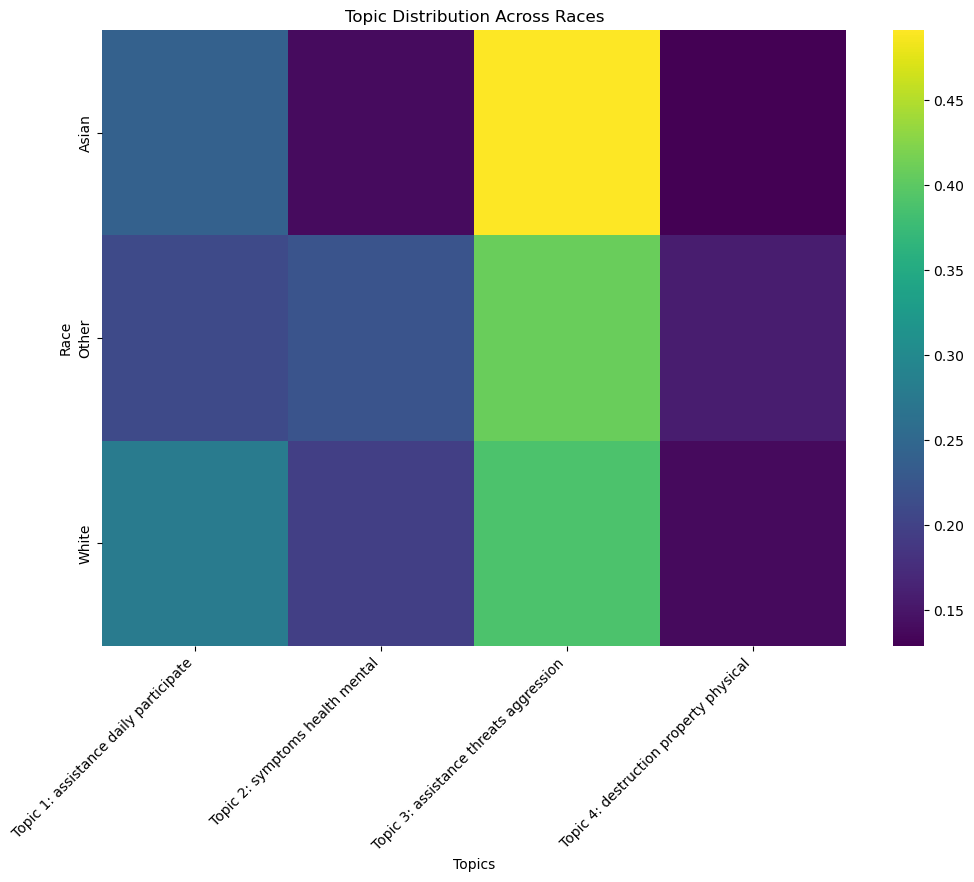

In [442]:
def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text)  
    text = re.sub(r'[^\w\s]', '', text)  
    text = text.lower()  
    return text
merged['cleaned_text'] = merged['Presenting problems at time of enrollment'].dropna().apply(preprocess_text)

# Tokenize text data
merged['tokenized_text'] = merged['cleaned_text'].apply(word_tokenize)
# Vectorize text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
text_data = vectorizer.fit_transform(merged['cleaned_text'])

# Apply LDA 
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(text_data)

# Display topics
def display_topics(model, feature_names, no_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        topic_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(" ".join(topic_words))
    return topics
no_top_words = 3

feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, no_top_words)
print("Topics found via LDA:")
for idx, topic in enumerate(topics):
    print(f"Topic {idx+1}: {topic}")

# Use top words as topic labels
topic_labels = [f'Topic {i+1}: {" ".join(feature_names[topic.argsort()[:-no_top_words - 1:-1]])}' for i, topic in enumerate(lda.components_)]

merged['Race_Fixed'] = merged['Race'].map(race_mapping).fillna('Other')

# Group by Race
topic_distribution = merged.groupby('Race_Fixed')['cleaned_text'].apply(lambda texts: ' '.join(texts))
topic_distribution = topic_distribution.apply(preprocess_text)
# Vectorize grouped text data
grouped_text_data = vectorizer.transform(topic_distribution)
grouped_topics = lda.transform(grouped_text_data)

topic_df = pd.DataFrame(grouped_topics, index=topic_distribution.index, columns=topic_labels)
# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(topic_df, annot=False, cmap='viridis')
plt.title('Topic Distribution Across Races')
plt.xlabel('Topics')
plt.ylabel('Race')
plt.xticks(rotation=45, ha='right')  
plt.show()


In [523]:

abc_by_disability = merged.groupby(['Type of Service', 'Level of Intellectual Disability'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()

# COUNT 
disability_counts = merged.groupby(['Type of Service', 'Level of Intellectual Disability']).size().reset_index(name='Count')

# Merge the mean scores WITHH the counts
abc_by_disability_with_counts = pd.merge(abc_by_disability, disability_counts, on=['Type of Service', 'Level of Intellectual Disability'])

intake_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Intake']
reeval_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Re-evaluation']
resource_center_data_disability = abc_by_disability_with_counts[abc_by_disability_with_counts['Type of Service'] == 'Resource Center admission']

intake_data_disability_sorted = intake_data_disability.sort_values(by='Count', ascending=False)
reeval_data_disability_sorted = reeval_data_disability.sort_values(by='Count', ascending=False)
resource_center_data_disability_sorted = resource_center_data_disability.sort_values(by='Count', ascending=False)

abc_by_disability_with_counts_sorted = pd.concat([intake_data_disability_sorted, reeval_data_disability_sorted, resource_center_data_disability_sorted])

print("\nMean ABC Scores by Level of Intellectual Disability and Type of Service with Counts (Sorted by Count within each Service Type):")
abc_by_disability_with_counts_sorted

# render this into somehting intuititve 
# heat map, x axis ordinal scale, 
# create pivot table where x axis is level of intellectual disability 

# use the text to predict on some y , could code intake and re-eval as dummies 


Mean ABC Scores by Level of Intellectual Disability and Type of Service with Counts (Sorted by Count within each Service Type):


,Type of Service,Level of Intellectual Disability,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,Count
1,Intake,Mild,24.716172,46.696530,19.933709,43.164153,36.744006,2164
2,Intake,Moderate,27.439824,49.525764,28.502935,46.837212,39.417808,1465
6,Intake,Severe,32.545932,53.041703,38.270677,51.859143,30.848725,381
3,Intake,None noted,31.175373,52.431177,33.347548,51.616915,38.622754,335
4,Intake,Normal intelligence,29.474812,52.509762,24.270353,48.774116,36.532258,315
0,Intake,Borderline,25.935039,46.780402,20.828646,45.464239,38.188976,254
5,Intake,Profound,29.103535,51.986532,37.373737,49.021465,23.989899,66
8,Re-evaluation,Mild,18.601949,35.434213,14.938586,31.554007,28.670021,6497
9,Re-evaluation,Moderate,19.850656,37.388977,20.615007,34.788728,31.079951,4406
13,Re-evaluation,Severe,24.733600,42.408331,29.299272,41.508649,26.878758,1008


In [524]:
# HOSPITALIZATION DATA 
abc_by_psych_hospitalization = merged.groupby(['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()

# Count occurrences
psych_hospitalization_counts = merged.groupby(['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)']).size().reset_index(name='Count')

# Merge mean scores with counts
abc_by_psych_hospitalization_with_counts = pd.merge(abc_by_psych_hospitalization, psych_hospitalization_counts, on=['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'])

# Filter rows where count is greater than 2
abc_by_psych_hospitalization_with_counts_filtered = abc_by_psych_hospitalization_with_counts[abc_by_psych_hospitalization_with_counts['Count'] > 5]

# Sort data by count within each service type
abc_by_psych_hospitalization_with_counts_sorted = abc_by_psych_hospitalization_with_counts_filtered.sort_values(by=['Type of Service', 'Count'], ascending=[True, False])

# Print the result
print("\nMean ABC Scores by Psychiatric Hospitalization and Type of Service with Counts (Sorted by Count within each Service Type):")
abc_by_psych_hospitalization_with_counts_sorted



Mean ABC Scores by Psychiatric Hospitalization and Type of Service with Counts (Sorted by Count within each Service Type):


,Type of Service,Psychiatric hospitalization in past year (at enrollment to START),norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,Count
0,Intake,No,26.945949,48.170602,26.425841,46.012052,37.016946,3241
3,Intake,Yes: 1,26.866943,48.260282,23.455812,45.556478,36.949686,905
8,Intake,Yes: 2,27.034884,51.285530,23.934109,48.758479,38.880814,345
10,Intake,Yes: 3,27.607442,49.979036,21.653190,43.160377,34.329140,160
11,Intake,Yes: 4,21.482684,47.619048,15.398887,38.961039,32.142857,77
13,Intake,Yes: 5,29.103535,57.474747,20.851371,47.916667,40.530303,66
2,Intake,Yes: 0,33.836207,64.904215,23.316913,51.795977,41.379310,29
15,Intake,Yes: 6,28.317901,56.296296,25.749559,48.996914,36.419753,27
4,Intake,Yes: 10,24.218750,51.527778,18.452381,43.098958,34.895833,16
18,Intake,Yes: 8,27.380952,59.841270,31.292517,48.809524,43.452381,14


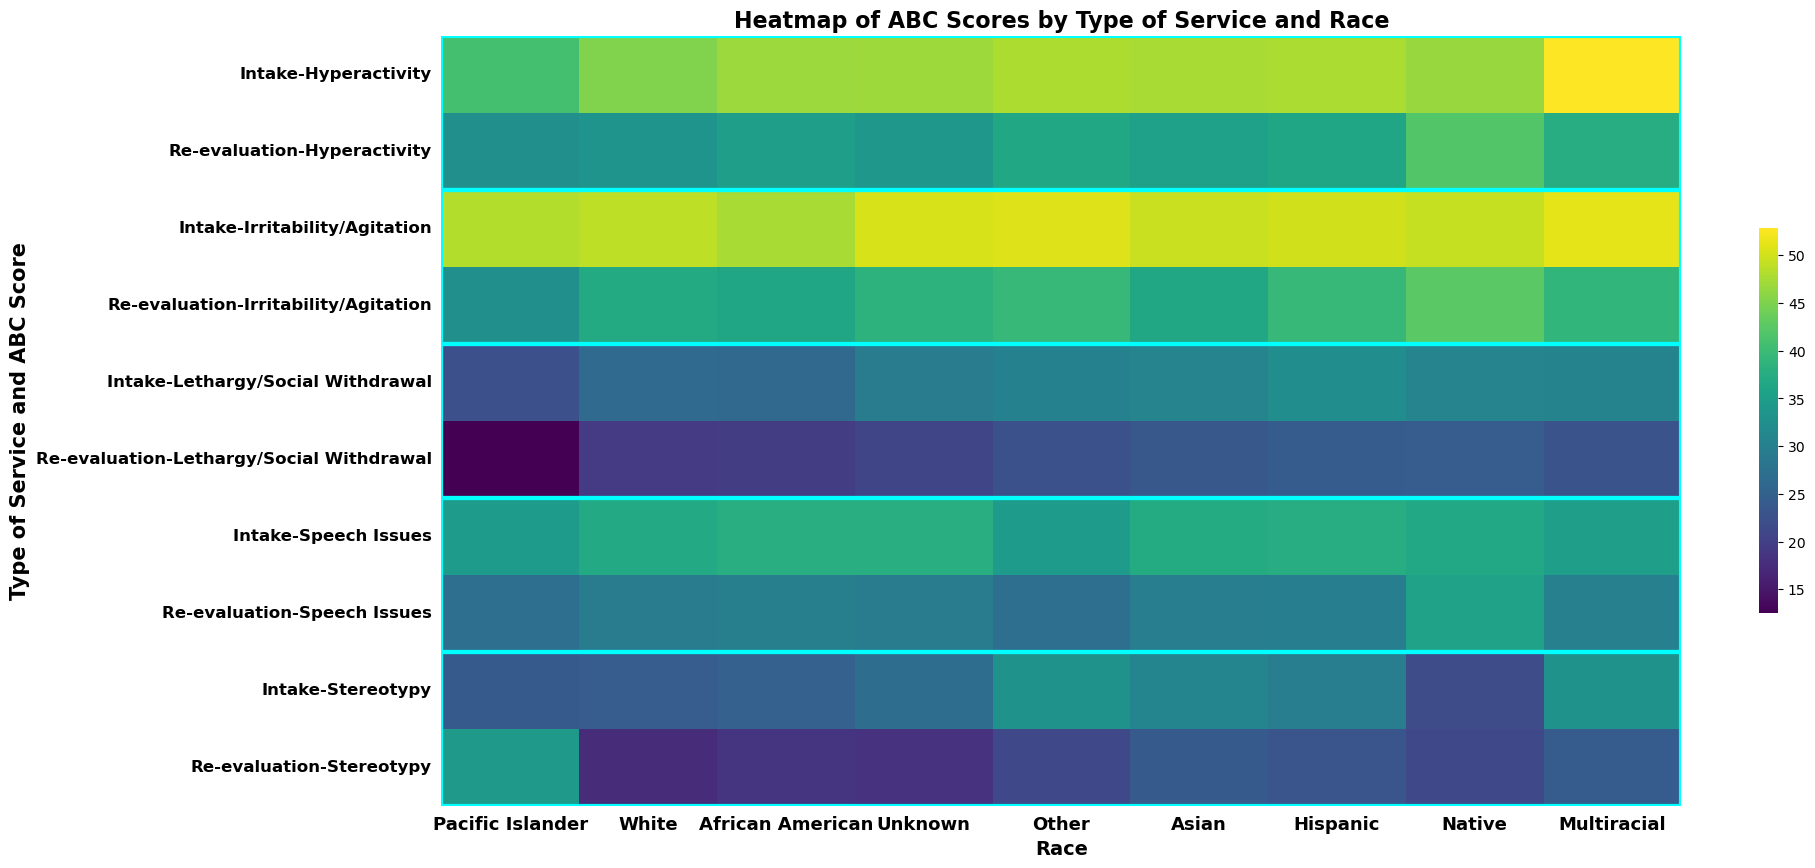

In [657]:

abc_by_service_gender = merged.groupby(['Type of Service', 'Race'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()
abc_melted = abc_by_service_gender.melt(
    id_vars=['Type of Service', 'Race'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Race', 
    values='Mean Value'
)
new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

order = []
abc_scores = list(rename_dict.values())
for score in abc_scores:
    order.append(('Intake', score))
    order.append(('Re-evaluation', score))

# Reorder the DataFrame by MEAN 
abc_pivot = abc_pivot.reindex(order)
mean_abc_scores = abc_pivot.mean().sort_values(ascending=True)
abc_pivot = abc_pivot[mean_abc_scores.index]
 

# Plotting the heatmap
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,  
    cmap='viridis',
    cbar_kws={'shrink': 0.5}
)

# Customizing tick labels and title for better readability
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=13, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

# Adding titles and labels
plt.title('Heatmap of ABC Scores by Type of Service and Race', fontsize=16, fontweight='bold')
plt.xlabel('Race', fontsize=14, fontweight='bold')
plt.ylabel('Type of Service and ABC Score', fontsize=15, fontweight='bold')

for i in range(0, len(abc_scores) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), len(mean_abc_scores), 2, fill=False, edgecolor='cyan', lw=3))  # Adjust edgecolor and lw as needed

# Display the plot
plt.show()


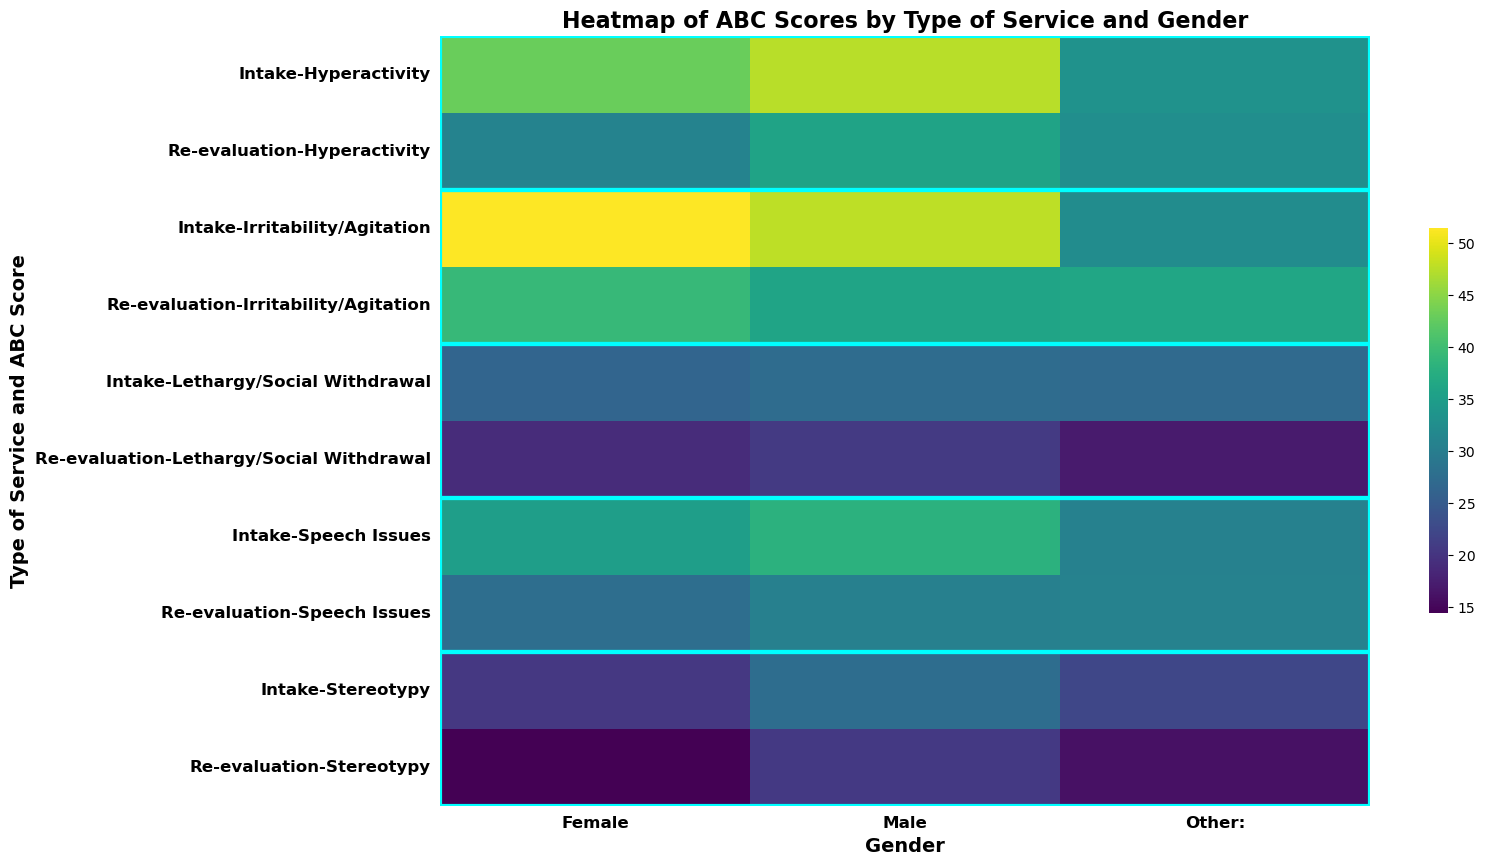

In [520]:
# Assuming `merged` is the DataFrame being used
abc_by_service_gender = merged.groupby(['Type of Service', 'Gender'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

# Melt the data for better handling in heatmap
abc_melted = abc_by_service_gender.melt(
    id_vars=['Type of Service', 'Gender'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)

# Pivot the melted data
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Gender', 
    values='Mean Value'
)

# Filter out the "Resource Center admission" service
abc_pivot = abc_pivot.loc[['Intake', 'Re-evaluation']]

# Create a dictionary for renaming
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

# Update the row indices with new labels
new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

# Create a list of the new desired order of the indices
order = []
abc_scores = list(rename_dict.values())
for score in abc_scores:
    order.append(('Intake', score))
    order.append(('Re-evaluation', score))

# Reorder the DataFrame
abc_pivot = abc_pivot.reindex(order)

# Plotting the heatmap
plt.figure(figsize=(15, 10))
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,  
    cmap='viridis',
    cbar_kws={'shrink': 0.5}
)

# Customizing tick labels and title for better readability
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

# Adding titles and labels
plt.title('Heatmap of ABC Scores by Type of Service and Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=14, fontweight='bold')
plt.ylabel('Type of Service and ABC Score', fontsize=14, fontweight='bold')


for i in range(0, len(abc_scores) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), 3, 2, fill=False, edgecolor='cyan', lw=3))  # Adjust edgecolor and lw as needed

# Display the plot
plt.show()


# Display the plot
plt.show()



Topics found via LDA:
Topic 1: assistance daily participate
Topic 2: symptoms health mental
Topic 3: assistance threats aggression
Topic 4: destruction property physical


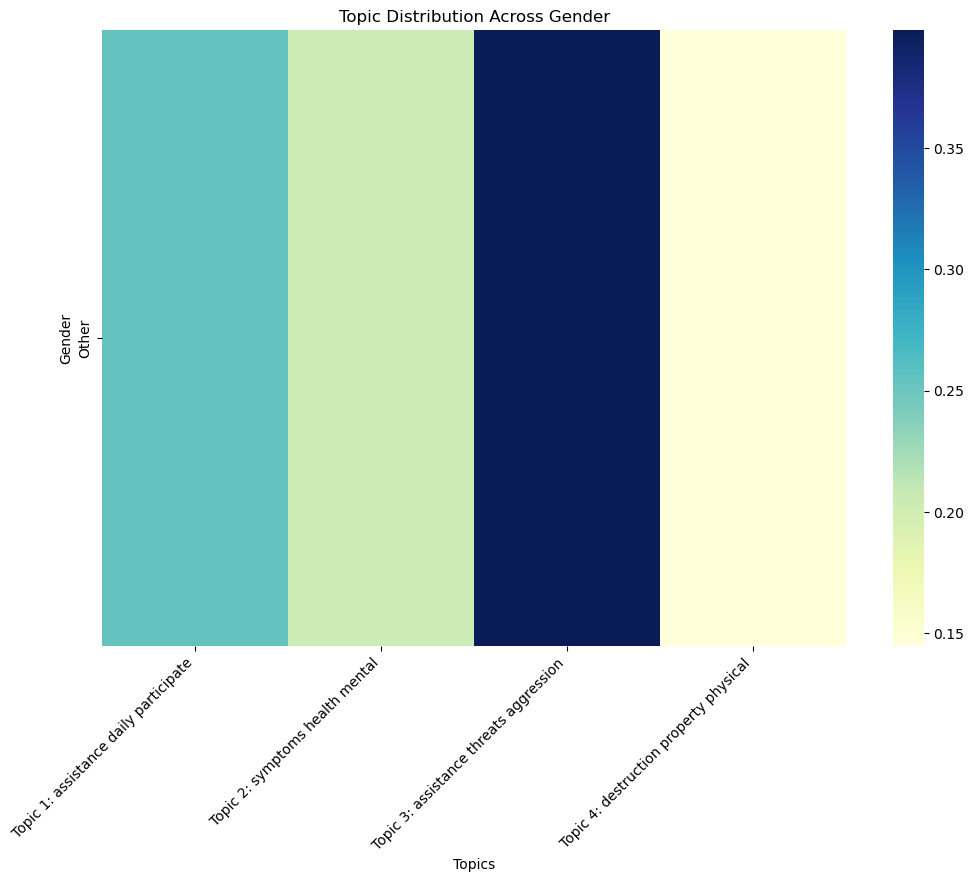

In [510]:
def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text)  
    text = re.sub(r'[^\w\s]', '', text)  
    text = text.lower()  
    return text
merged['cleaned_text'] = merged['Presenting problems at time of enrollment'].dropna().apply(preprocess_text)

# Tokenize text data
merged['tokenized_text'] = merged['cleaned_text'].apply(word_tokenize)
# Vectorize text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
text_data = vectorizer.fit_transform(merged['cleaned_text'])

# Apply LDA 
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(text_data)

# Display topics
def display_topics(model, feature_names, no_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        topic_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(" ".join(topic_words))
    return topics
no_top_words = 3

feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, no_top_words)
print("Topics found via LDA:")
for idx, topic in enumerate(topics):
    print(f"Topic {idx+1}: {topic}")

# Use top words as topic labels
topic_labels = [f'Topic {i+1}: {" ".join(feature_names[topic.argsort()[:-no_top_words - 1:-1]])}' for i, topic in enumerate(lda.components_)]

merged['Gender'] = merged['Gender'].map(race_mapping).fillna('Other')

# Group by Race
topic_distribution = merged.groupby('Gender')['cleaned_text'].apply(lambda texts: ' '.join(texts))
topic_distribution = topic_distribution.apply(preprocess_text)
# Vectorize grouped text data
grouped_text_data = vectorizer.transform(topic_distribution)
grouped_topics = lda.transform(grouped_text_data)

topic_df = pd.DataFrame(grouped_topics, index=topic_distribution.index, columns=topic_labels)
# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(topic_df, annot=False, cmap='YlGnBu')
plt.title('Topic Distribution Across Gender')
plt.xlabel('Topics')
plt.ylabel('Gender')
plt.xticks(rotation=45, ha='right')  
plt.show()


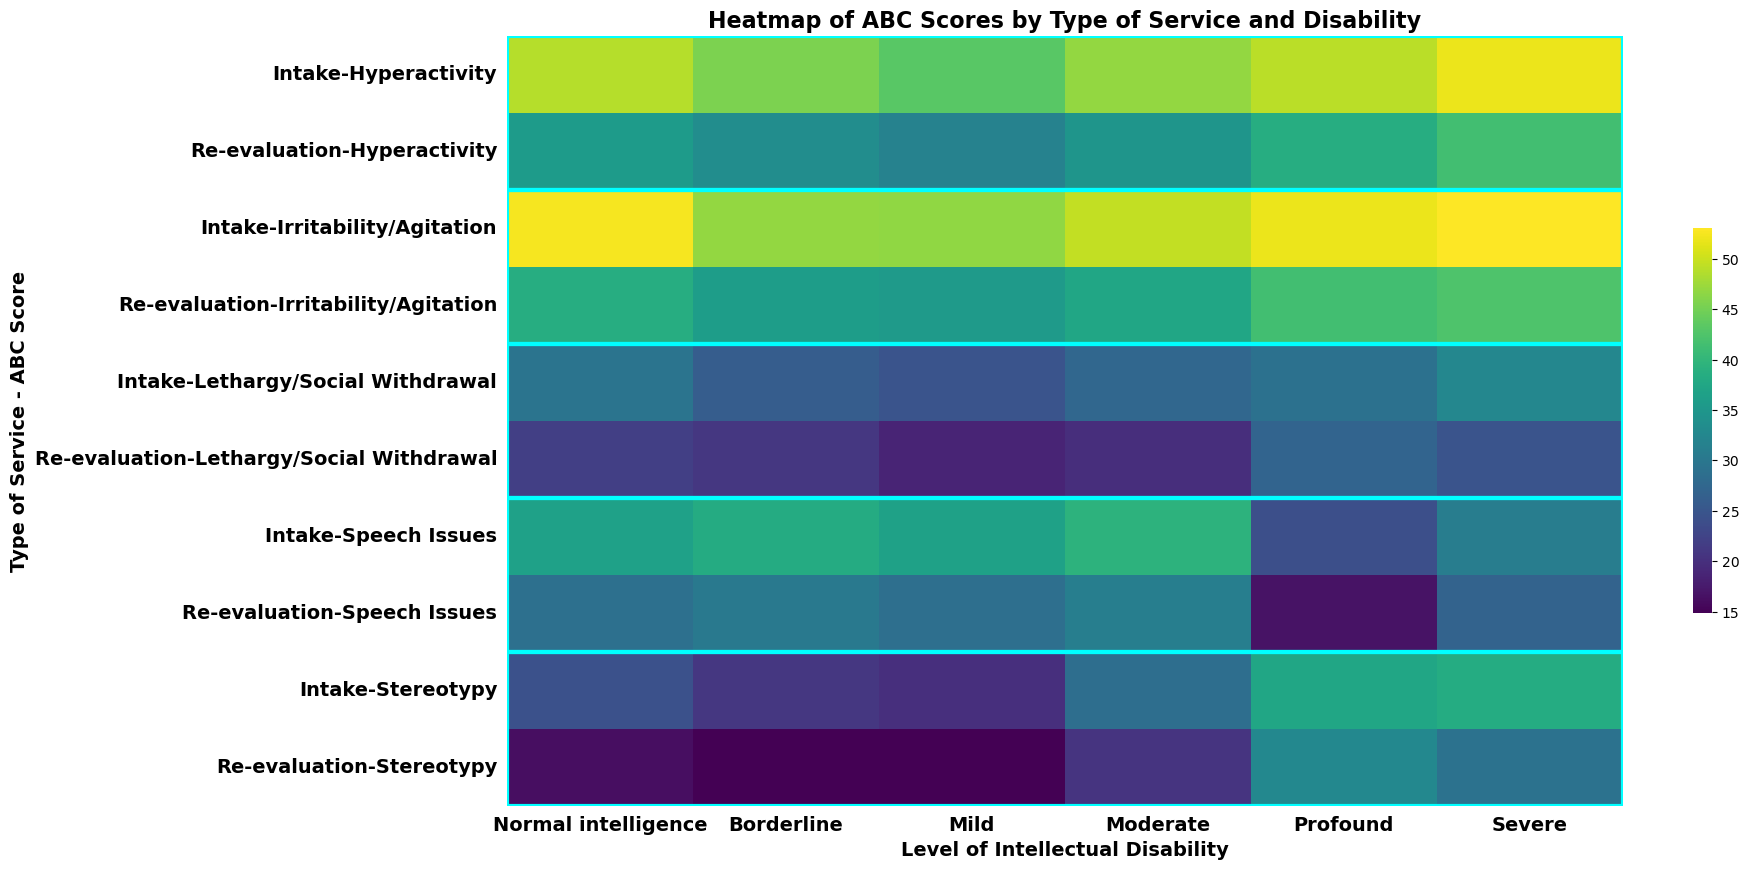

In [528]:

abc_by_service_disability = merged.groupby(['Type of Service', 'Level of Intellectual Disability'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

# Melt the dataframe for easier manipulation
abc_melted = abc_by_service_disability.melt(
    id_vars=['Type of Service', 'Level of Intellectual Disability'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)

# Pivot the table for the heatmap
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Level of Intellectual Disability', 
    values='Mean Value'
)

# Reorder the services
service_order = ['Intake', 'Re-evaluation']
abc_pivot = abc_pivot.reindex(service_order, level='Type of Service')

# Rename the ABC scores
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

# Reorder the index
order = []
abc_scores = list(rename_dict.values())
for score in abc_scores:
    order.append(('Intake', score))
    order.append(('Re-evaluation', score))
abc_pivot = abc_pivot.reindex(order)

# Define the order of disability levels
disability_order = ['Normal intelligence', 'Borderline', 'Mild', 'Moderate', 'Profound', 'Severe']
abc_pivot = abc_pivot[disability_order]

# Plot the heatmap
plt.figure(figsize=(18, 10)) 
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,
    cmap='viridis',
    cbar_kws={'shrink': 0.5}  
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=14, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=14, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

for i in range(0, len(abc_scores) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), len(disability_order), 2, fill=False, edgecolor='cyan', lw=3))
plt.title('Heatmap of ABC Scores by Type of Service and Disability', fontsize=16, fontweight='bold')
plt.xlabel('Level of Intellectual Disability', fontsize=14, fontweight='bold')
plt.ylabel('Type of Service - ABC Score', fontsize=14, fontweight='bold')
plt.show()


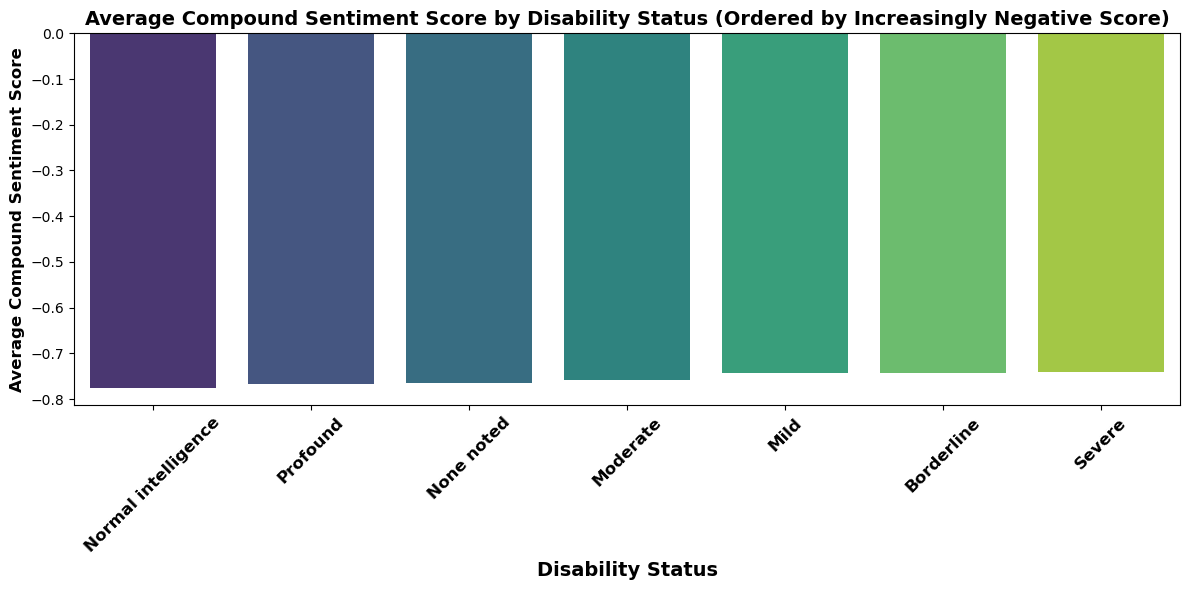

In [592]:
sentiment_by_disability = merged.groupby('Level of Intellectual Disability')['compound_score'].mean().reset_index()

# Sort by increasingly negative score
sentiment_by_disability_sorted = sentiment_by_disability.sort_values(by='compound_score')

# Plot the results by disability status
plt.figure(figsize=(12, 6))
sns.barplot(data=sentiment_by_disability_sorted, x='Level of Intellectual Disability', y='compound_score', palette='viridis')
plt.title('Average Compound Sentiment Score by Disability Status (Ordered by Increasingly Negative Score)', fontsize=14, fontweight='bold')
plt.xlabel('Disability Status', fontsize=14, fontweight='bold')
plt.ylabel('Average Compound Sentiment Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

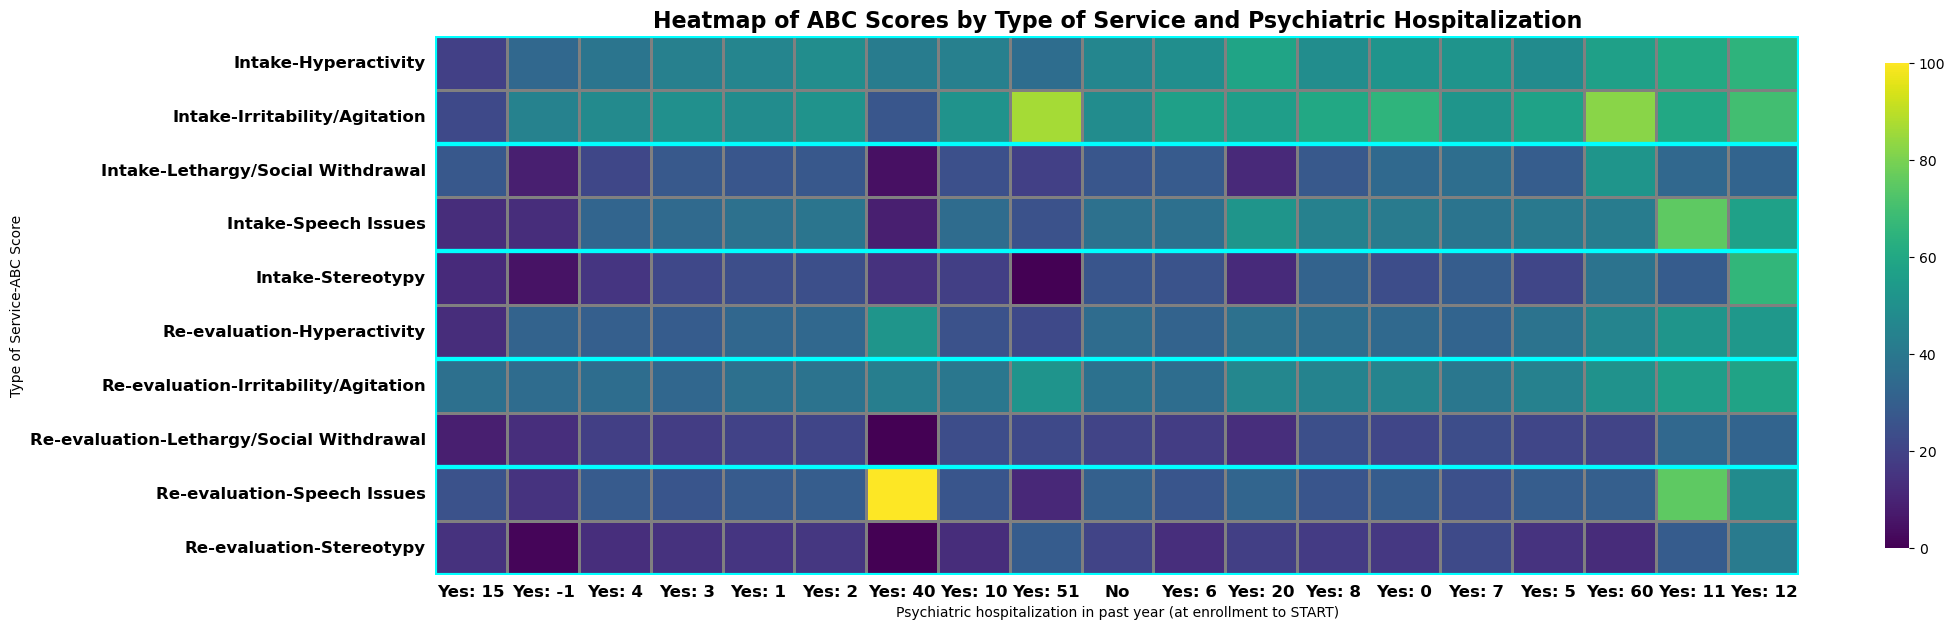

In [556]:
# Group by 'Type of Service' and 'Psychiatric hospitalization in past year (at enrollment to START)', calculate mean ABC scores
abc_by_service_hospitalization = merged.groupby(['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

# Melt the data for better handling in heatmap
abc_melted = abc_by_service_hospitalization.melt(
    id_vars=['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)

# Pivot the melted data
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Psychiatric hospitalization in past year (at enrollment to START)', 
    values='Mean Value'
)

# Filter out the rows for "Resource Center admission" service
abc_pivot = abc_pivot.loc[['Intake', 'Re-evaluation']]

# Create a dictionary for renaming
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

# Update the row indices with new labels
new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

# Create a list of the new desired order of the indices based on mean ABC scores
mean_abc_scores = abc_by_service_hospitalization.groupby('Psychiatric hospitalization in past year (at enrollment to START)')[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean()
sorted_hospitalizations = mean_abc_scores.mean(axis=1).sort_values(ascending=True).index
abc_pivot = abc_pivot[sorted_hospitalizations]

# Plotting the heatmap
plt.figure(figsize=(22, 7))
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,
    cmap='viridis',
    linewidths=1,
    linecolor='grey',
    cbar_kws={'shrink': 0.9}
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

for i in range(0, len(rename_dict) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), len(sorted_hospitalizations), 2, fill=False, edgecolor='cyan', lw=3))
plt.title('Heatmap of ABC Scores by Type of Service and Psychiatric Hospitalization', fontsize=16, fontweight='bold')
plt.show()


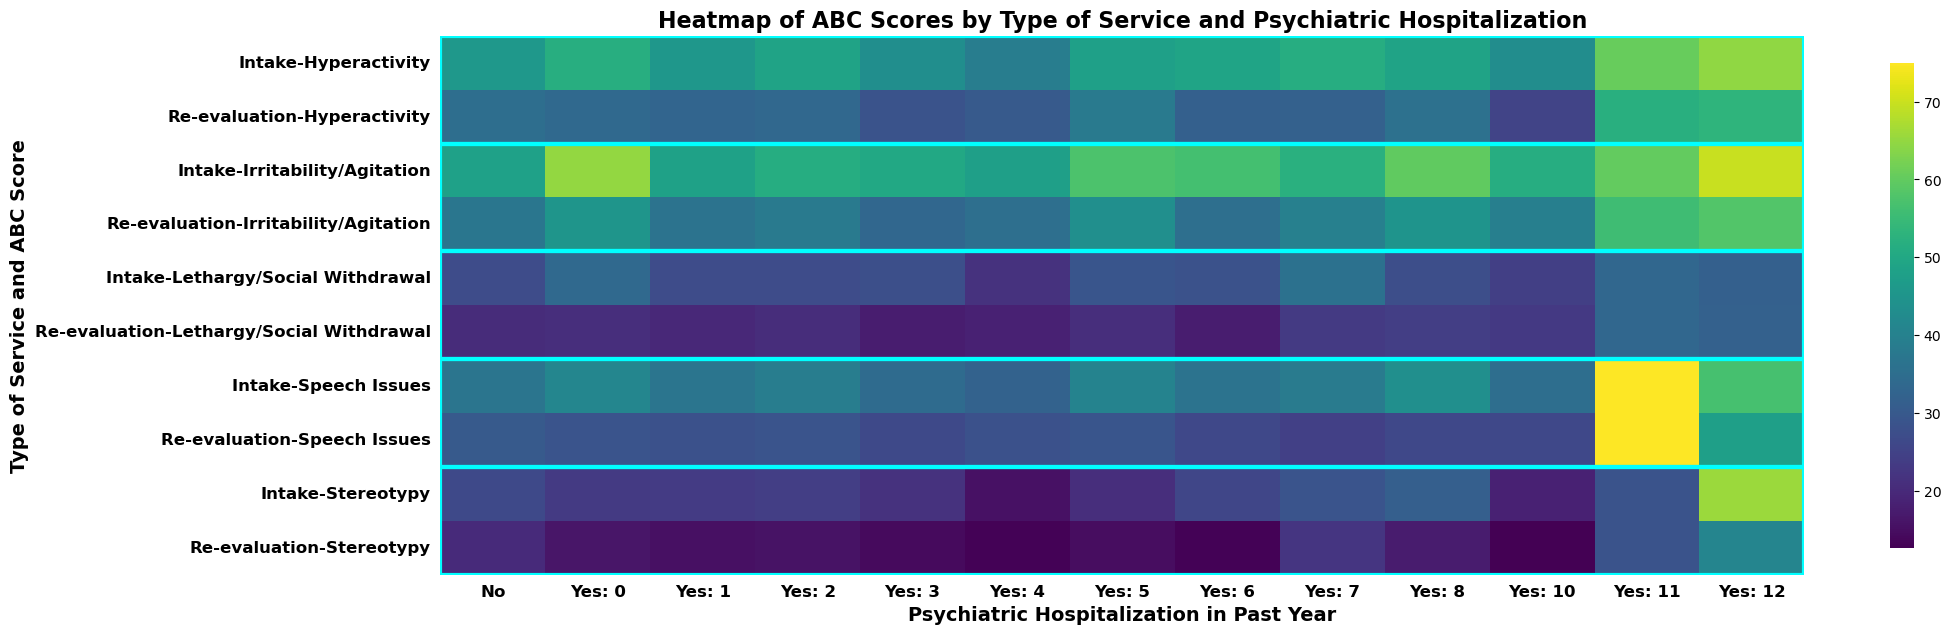

In [558]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'merged' DataFrame is already defined and contains the necessary columns

# Group by 'Type of Service' and 'Psychiatric hospitalization in past year (at enrollment to START)', calculate mean ABC scores
abc_by_service_hospitalization = merged.groupby(['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

# Melt the data for better handling in heatmap
abc_melted = abc_by_service_hospitalization.melt(
    id_vars=['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)

# Pivot the melted data
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Psychiatric hospitalization in past year (at enrollment to START)', 
    values='Mean Value'
)

# Filter out the rows for "Resource Center admission" service
abc_pivot = abc_pivot.loc[['Intake', 'Re-evaluation']]

# Create a dictionary for renaming
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

# Update the row indices with new labels
new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

# Define the order for psychiatric hospitalization
hosp_order = ['No','Yes: 0', 'Yes: 1', 'Yes: 2', 'Yes: 3', 'Yes: 4', 'Yes: 5', 'Yes: 6', 'Yes: 7', 'Yes: 8', 'Yes: 10', 'Yes: 11', 'Yes: 12']
abc_pivot = abc_pivot[hosp_order]

# Define the order for the y-axis to alternate between Intake and Re-evaluation for each ABC Score
order = []
abc_scores = list(rename_dict.values())
for score in abc_scores:
    order.append(('Intake', score))
    order.append(('Re-evaluation', score))
abc_pivot = abc_pivot.reindex(order)

# Plotting the heatmap
plt.figure(figsize=(22, 7))
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,
    cmap='viridis',
    cbar_kws={'shrink': 0.9}
)

heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

# Add rectangle patches to distinguish groups
for i in range(0, len(rename_dict) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), len(hosp_order), 2, fill=False, edgecolor='cyan', lw=3))

plt.title('Heatmap of ABC Scores by Type of Service and Psychiatric Hospitalization', fontsize=16, fontweight='bold')
plt.xlabel('Psychiatric Hospitalization in Past Year', fontsize=14, fontweight='bold')
plt.ylabel('Type of Service and ABC Score', fontsize=14, fontweight='bold')
plt.show()


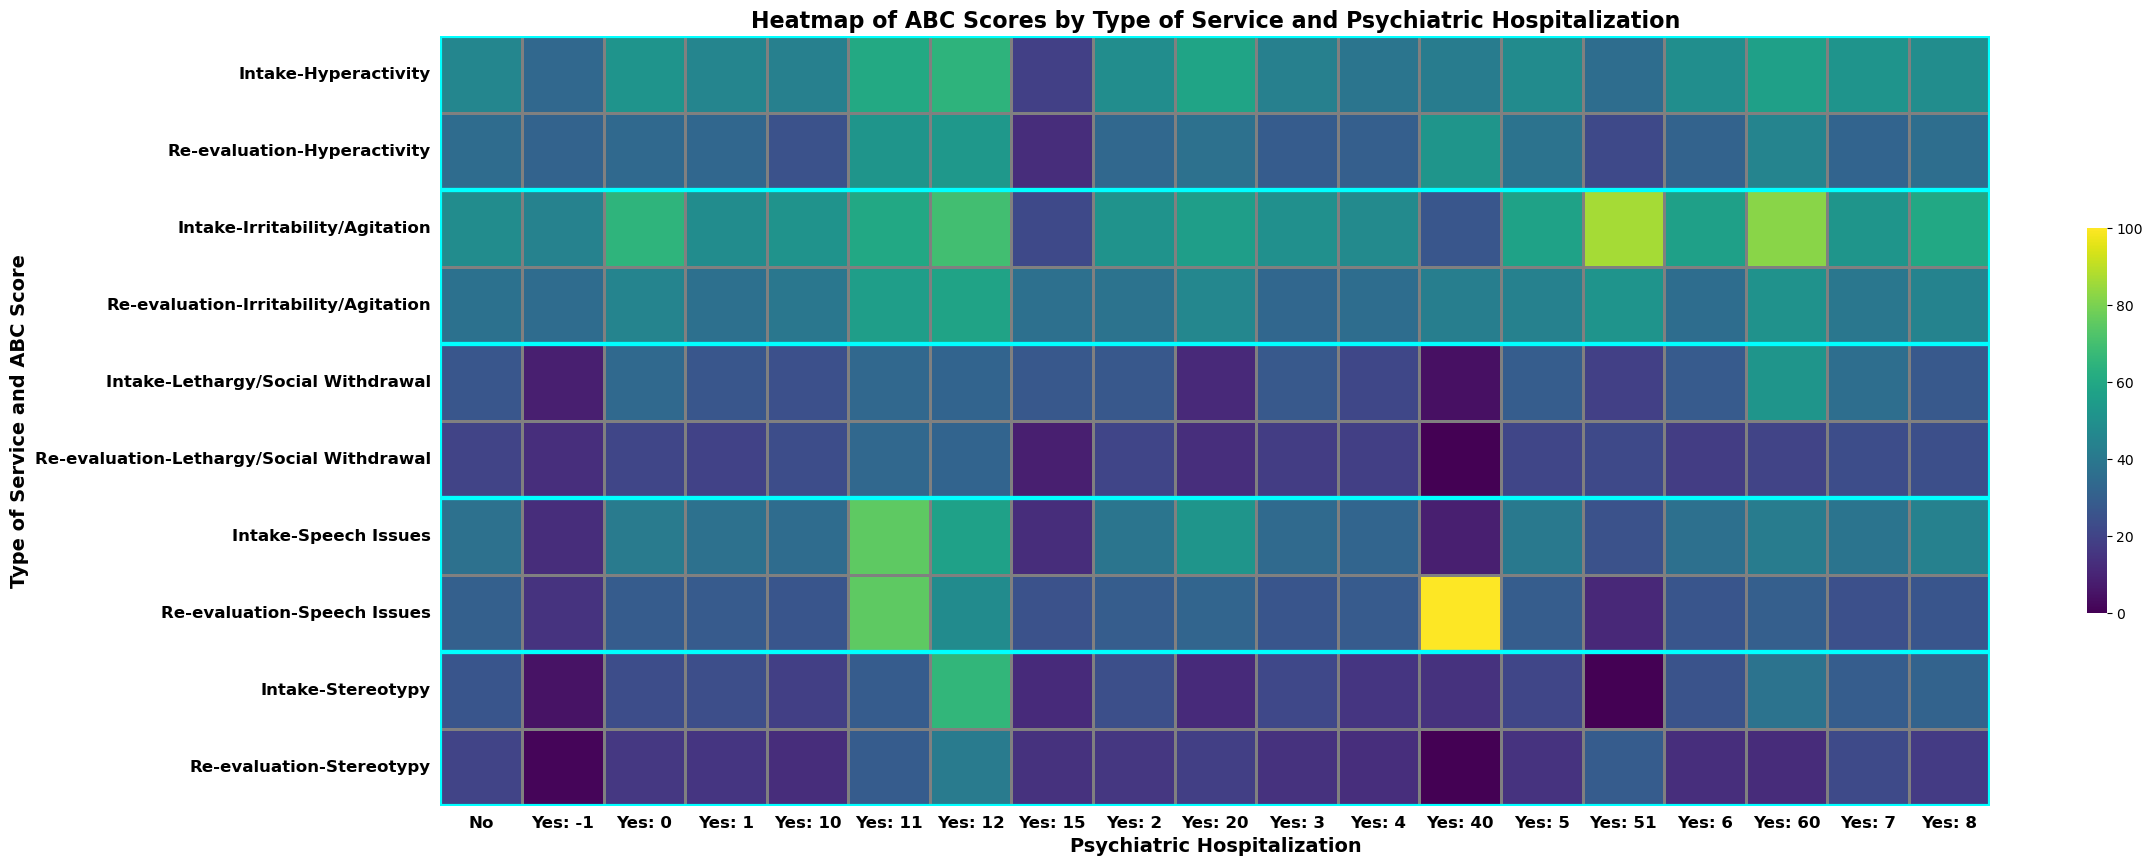

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'merged' DataFrame and other necessary variables are already defined

# Group by 'Type of Service' and 'Psychiatric hospitalization in past year (at enrollment to START)', calculate mean ABC scores
abc_by_service_hospitalization = merged.groupby(['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'])[['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']].mean().reset_index()

# Melt the data for better handling in heatmap
abc_melted = abc_by_service_hospitalization.melt(
    id_vars=['Type of Service', 'Psychiatric hospitalization in past year (at enrollment to START)'], 
    value_vars=['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech'],
    var_name='ABC Score', value_name='Mean Value'
)

# Pivot the melted data
abc_pivot = abc_melted.pivot_table(
    index=['Type of Service', 'ABC Score'], 
    columns='Psychiatric hospitalization in past year (at enrollment to START)', 
    values='Mean Value'
)

# Filter out the rows for "Resource Center admission" service
abc_pivot = abc_pivot.loc[['Intake', 'Re-evaluation']]

# Create a dictionary for renaming
rename_dict = {
    'norm_hyper': 'Hyperactivity',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_speech': 'Speech Issues',
    'norm_stereo': 'Stereotypy'
}

# Update the row indices with new labels
new_index = [(service, rename_dict[abc_score]) for (service, abc_score) in abc_pivot.index]
abc_pivot.index = pd.MultiIndex.from_tuples(new_index, names=['Type of Service', 'ABC Score'])

# Create a list of the new desired order of the indices
order = []
abc_scores = list(rename_dict.values())
for score in abc_scores:
    order.append(('Intake', score))
    order.append(('Re-evaluation', score))

# Reorder the DataFrame
abc_pivot = abc_pivot.reindex(order)

# Plotting the heatmap
plt.figure(figsize=(25, 10))
heatmap = sns.heatmap(
    abc_pivot,
    annot=False,  # Disable annotations for numbers inside the map
    cmap='viridis',
    linewidths=1,
    linecolor='grey',
    cbar_kws={'shrink': 0.5}
)

# Customizing tick labels and title for better readability
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12, fontweight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, fontweight='bold')
heatmap.tick_params(left=False, bottom=False)

# Adding titles and labels
plt.title('Heatmap of ABC Scores by Type of Service and Psychiatric Hospitalization', fontsize=16, fontweight='bold')
plt.xlabel('Psychiatric Hospitalization', fontsize=14, fontweight='bold')
plt.ylabel('Type of Service and ABC Score', fontsize=14, fontweight='bold')


for i in range(0, len(abc_scores) * 2, 2):
    plt.gca().add_patch(plt.Rectangle((0, i), 19, 2, fill=False, edgecolor='cyan', lw=3))  # Adjust edgecolor and lw as needed

# Display the plot
plt.show()


In [41]:
# Mary (Coefficient Plot)

# Columns of interest: Race, Gender, Level of Intellectual Disability, CPS History, Psychiatric, Moved in Past 5 Years

# Calculating Mean ABC Score Across All Columns 

#cols_of_interest = merged[["Race", "Gender", "Level of Intellectual Disability", "More than one living situation over the last 5 years?",
                    #"History of Child Protective Services involvement in past year (at enrollment to START)", 
                    #"Psychiatric hospitalization in past year (at enrollment to START)"]]

mean_cols = merged[["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"]]

merged.dropna(subset=["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"], inplace = True)

merged["mean_abc"] = mean_cols.mean(axis = 1)

merged


,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech,Date Enrolled in START,Status,...,norm_ir_agit,norm_stereo,norm_hyper,norm_speech,sentiments,compound_score,cleaned_text,tokenized_text,Race_Fixed,mean_abc
0,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0,4/1/2013,Active,...,6.666667,0.000000,0.000000,0.000000,"{'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...",-0.9509,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,2.166667
3,11153125,6/21/2018,Re-evaluation,19.0,19.0,4.0,8.0,0.0,4/1/2013,Active,...,42.222222,19.047619,16.666667,0.000000,"{'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...",-0.9509,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,23.503968
4,11153125,9/24/2018,Re-evaluation,10.0,11.0,3.0,6.0,2.0,4/1/2013,Active,...,22.222222,14.285714,12.500000,16.666667,"{'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...",-0.9509,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,17.718254
5,11153125,1/28/2019,Re-evaluation,21.0,9.0,0.0,7.0,2.0,4/1/2013,Active,...,46.666667,0.000000,14.583333,16.666667,"{'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...",-0.9509,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,19.333333
6,11153125,9/19/2019,Re-evaluation,22.0,10.0,0.0,7.0,0.0,4/1/2013,Active,...,48.888889,0.000000,14.583333,0.000000,"{'neg': 0.599, 'neu': 0.401, 'pos': 0.0, 'comp...",-0.9509,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,16.861111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19456,66474,11/29/2021,Re-evaluation,0.0,0.0,0.0,0.0,0.0,7/1/2020,Active,...,0.000000,0.000000,0.000000,0.000000,"{'neg': 0.465, 'neu': 0.535, 'pos': 0.0, 'comp...",-0.8271,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",Other,0.000000
19457,445217,11/29/2021,Re-evaluation,8.0,6.0,5.0,11.0,1.0,4/1/2020,Active,...,17.777778,23.809524,22.916667,8.333333,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,leaving unexpectedly,"[leaving, unexpectedly]",Other,17.067460
19458,421066,12/3/2021,Re-evaluation,34.0,15.0,17.0,32.0,6.0,4/1/2020,Active,...,75.555556,80.952381,66.666667,50.000000,"{'neg': 0.434, 'neu': 0.51, 'pos': 0.056, 'com...",-0.9393,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",White,60.884921
19459,312733,11/17/2021,Re-evaluation,5.0,1.0,0.0,5.0,1.0,5/1/2020,Active,...,11.111111,0.000000,10.416667,8.333333,"{'neg': 0.595, 'neu': 0.405, 'pos': 0.0, 'comp...",-0.9217,aggression physical verbal property destructio...,"[aggression, physical, verbal, property, destr...",Other,6.388889


In [42]:
# Mapping Gender

mapping = {
    0: 'Male',
    1: 'Female'}

# Define the map_gender function
def map_gender(value):
    if value in mapping:
        return mapping[value]
    else:
        return 2

merged['Gender_mapped'] = merged['Gender'].apply(map_gender)

# Mapping Race

race_mapping = {
    'White': 1,
    'Black or African American': 2,
    'Unknown, not collected': 3,
    'Other: Hispanic': 4,
    'Asian': 5,
    'Other': 6,
    'Black or African American, White': 7,
    'Other: Latino': 8,
    'American Indian or Alaska Native': 9,
    'Other: hispanic': 10,
    'Asian, White': 11,
    'Other: Mexican': 12,
    'Unknown, not collected, White': 13,
    'Native Hawaiian or Other Pacific Islander': 14,
    'Other: Biracial': 15,
    'Other: Hispanic, White': 15,
    'Other: Bi-racial': 15,
    'Other: East Indian': 16,
    'Asian, Black or African American': 15,
    'Other: Indian': 16,
    'Black or African American, Unknown, not collected': 15,
    'Other: Middle Eastern': 16,
    'American Indian or Alaska Native, White': 15,
    'Other: Guyanese': 17,
    'Other: Filipino': 17,
    'Other: Hispanic - Puerto Rican descent': 18,
    'Other: Puerto Rican': 18,
    'Other: Mixed race': 15,
    'Other: Mixed Race': 15,
    'Native Hawaiian or Other Pacific Islander, White': 15,
    'Other: "Hispanic"': 18,
    'Other: Latina': 18,
    'Other: Latin  American': 18,
    'Other: Jordanian': 17,
    'Other: Pakistan, Unknown, not collected': 17,
    'Other: Hispanic/Latino': 'Hispanic',
    'Black or African American, Other: Hispanic': 15,
    'Black or African American, Other: Guyanese': 15,
    'Other: Russian': 17,
    'Other: West Indian': 17,
    'Asian, Other: Indian': 15,
    'Other: HISPANIC': 18,
    'Other: Guyanses': 17,
    'Asian, Other: Pakistani': 16,
    'American Indian or Alaska Native, Black or African American': 15,
    'Other: Ethiopian': 17,
    'Other: Egyptian': 17,
    'Other: biracial': 15,
    'Other: Colombian': 17,
    'Other: Did not want to Identity with Race or Ethnicity': 'Unknown',
    'Other: Dominican': 17,
    'Other: Chinese': 17,
    'Other: Eastern European': 17,
    'Other: Ecuador': 17,
    'Other: Ecuadorian': 17,
    'Other: Caucasian and African Amercian': 15,
    'Other: Caucasian': 1,
    'Other: Eurasian': 15,
    'Other: Carribean Indian': 16,
    'Other: Filipino and Caucasian': 15,
    'Other: Bosnian': 16,
    'Other: Black Hispanic': 15,
    'Other: HIspanic': 'Hispanic',
    'Other: Hispanic ': 'Hispanic',
    'Other: Hispanic (Uruguayan/Dominican)': 18,
    'Other: Hispanic - Puerto Rican': 18,
    'Other: Hispanic, AA and white': 15,
    'Other: Hispanic, Unknown, not collected': 18,
    'Other: Bi-Racial': 15,
    'Other: Hispanic/ Latina': 18,
    'Other: Bengalii': 16,
    'Other: Hispanic: Puerto Rican': 18,
    'Other: Hondurian': 18,
    'Other: Bengali': 16,
    'Other: Indian of Guyanese decent': 15,
    'Other: Indian which decent unknown': 15,
    'Other: Iraq': 17,
    'Other: Iraqi': 17,
    'Other: Irish': 17,
    'Other: Israel': 17,
    'Other: Jamaican American': 'Black or African American',
    'Other: Jewish': 17,
    'Other: Bangladish': 17,
    'Other: Baltic ethnic group (Latvian)': 17,
    'Other: Arab': 16,
    'Other: Albian/European': 17,
    'Other: Latino ( Mexican & Puerto Rican )': 18,
    'Other: Latino (Guatemalen & El Salvador)': 18,
    'Other: Latino, White': 18,
    'Other: MIXED RACE, White': 15,
    'Other: MIddle Eastern- North African Descent, ': 16,
    'Other: Mauritius': 17,
    'Other: African-American/Vietnamese': 15,
    'Other: Mexican/Puerto Rican': 17,
    'Other: Middle Eastern Decent': 16,
    'Other: South African': 17,
    'Other: South American': 17,
    'Other: Spanish': 17,
    'Other: Vietnamese': 17,
    'Other: Vietnamesse': 17,
    'Other: unknown': 17,
    'Other: White and Asian': 15,
    'Other: White and Black or African America': 15,
        'Other: puerto rican': 17,
    'Asian, Black or African American, White': 15,
    'Asian, Native Hawaiian or Other Pacific Islander': 15,
    'Asian, Other: Filipino': 15,
    'Asian, Other: Hispanic': 15,
    'Other: not checked off': 17,
    'Other: myanmar': 17,
    'Other: mother is white and father is 1/2 white': 15,
    'Other: White, Hispanic': 15,
    'Other: White/Indian': 15,
    'Asian, Other: vietnamese': 15,
    'Other: mixed race': 15,
    'Other: hispanic, White': 15,
    'Other: latino/white': 18,
    'Other: mexican': 17,
    'American Indian or Alaska Native, Other: Native Hawaiian or Other Pacific Islander': 15,
    'Other:': 16  
}

# Group by "Type of Service" and "Race" and calculate mean ABC scores
merged['Race_Fixed'] = merged['Race'].map(race_mapping).fillna('Other')

In [46]:
# Creating the Design Matrix 

design_matrix = pd.get_dummies(merged, columns=["Race", "Gender", "Level of Intellectual Disability",
                                                "More than one living situation over the last 5 years?",
                                                "History of Child Protective Services involvement in past year (at enrollment to START)",
                                                "Psychiatric hospitalization in past year (at enrollment to START)"])


In [47]:
# Creating the Coefficient Plot 

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Fit linear regression model
model = sm.OLS.from_formula('mean_abc ~ ' + ' + '.join(design_matrix.columns[1:]), data = design_matrix).fit()

# Get coefficients summary
coefs_sumz = model.params
coefs_std_err = model.bse

# Extract coefficients and standard errors
coefz_df = pd.DataFrame({
    'outcome': design_matrix.columns[1:],
    'coefs': coefs_sumz.values[1:],
    'ses': coefs_std_err.values[1:]
})

# Plot coefficients
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x = 'outcome', y = 'coefs', data = coefz_df, ci = None, color = 'skyblue')
plt.errorbar(x = coefz_df['outcome'], y = coefz_df['coefs'], yerr = 1.96*coefz_df['ses'], fmt = 'none', c = 'red', capsize = 5)
plt.axhline(y = 0, color = 'red', linestyle='--', linewidth = 0.6)
plt.xlabel('Outcome')
plt.ylabel('Effect')
plt.title('Support of Nuclear Energy by Country')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()



PatsyError: error tokenizing input (maybe an unclosed string?)
    mean_abc ~ Date Reviewed + Type of Service + Irritability/Agitation + Lethargy/Social Withdrawal + Stereotypic Behavior + Hyperactivity/Noncompliance + Inappropriate Speech + Date Enrolled in START + Status + Status Date + Time Enrolled in START + Source of referral to START + Suitability of enrollment in START + Individual/Caregiver reliable access to technology + Presenting problems at time of enrollment + Services at Enrollment + DOB + Ethnicity + Current living situation at enrollment to START + More than one living situation over the last year? + Psychiatric hospitalizations in past 1 - 5 years (at enrollment to START) + Emergency department visits in past year (at enrollment to START) + Emergency department visits in past 1-5 years (at enrollment to START) + Law enforcement encounters in past year (at enrollment to START) + Law enforcement encounters in past 1 - 5 years (at enrollment to START) + Psychiatric diagn

/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_25145/661958879.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  merged['Date Reviewed'] = pd.to_datetime(merged['Date Reviewed'], errors='coerce', infer_datetime_format=True)


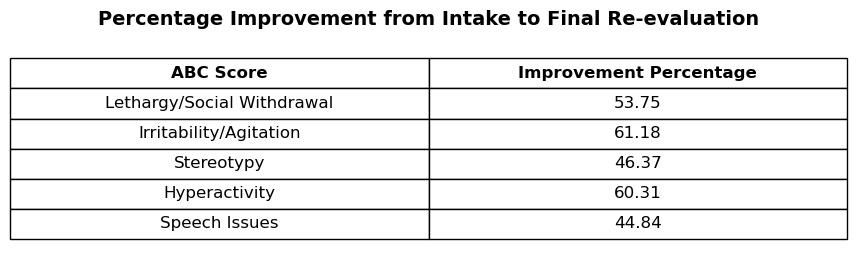

In [554]:
improved_scores = merged.copy
merged['Date Reviewed'] = pd.to_datetime(merged['Date Reviewed'], errors='coerce', infer_datetime_format=True)


merged = merged.sort_values(by=['Local ID', 'Date Reviewed'])

# Get the intake (first entry) and last re-evaluation for each 'Local ID'
intake_df = merged.groupby('Local ID').first().reset_index()
last_reeval_df = merged.groupby('Local ID').last().reset_index()

# Merge the intake and last re-evaluation DataFrames
comparison_df = pd.merge(intake_df, last_reeval_df, on='Local ID', suffixes=('_intake', '_last_reeval'))

score_columns = ['norm_leth_soc', 'norm_ir_agit', 'norm_stereo', 'norm_hyper', 'norm_speech']
for score in score_columns:
    comparison_df[f'{score}_improved'] = (comparison_df[f'{score}_last_reeval'] < comparison_df[f'{score}_intake']).astype(int)



for score in score_columns:
    comparison_df[f'{score}_improved'] = (comparison_df[f'{score}_last_reeval'] < comparison_df[f'{score}_intake']).astype(int)

# Calculate the percentage improvements
improvements = {score: sum(comparison_df[f'{score}_improved']) / len(comparison_df) * 100 for score in score_columns}

# Create a DataFrame for visualization
improvements_df = pd.DataFrame(list(improvements.items()), columns=['ABC Score', 'Improvement Percentage'])
improvements_df['ABC Score'] = improvements_df['ABC Score'].replace({
    'norm_leth_soc': 'Lethargy/Social Withdrawal',
    'norm_ir_agit': 'Irritability/Agitation',
    'norm_stereo': 'Stereotypy',
    'norm_hyper': 'Hyperactivity',
    'norm_speech': 'Speech Issues'
})
improvements_df['Improvement Percentage'] = improvements_df['Improvement Percentage'].round(2)

fig, ax = plt.subplots(figsize=(9, 3))  # set size frame
ax.axis('off')
table = ax.table(cellText=improvements_df.values, colLabels=improvements_df.columns, cellLoc='center', loc='center')
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(fontweight='bold')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)  # scale size of table to make rows taller

plt.title('Percentage Improvement from Intake to Final Re-evaluation', fontsize=14, fontweight='bold')
plt.show()